# TP - Data Integration & Applications (ST2DLDI)
### Anaëlle Pollart

Dataset: French Road Safety Open Data, "Bases de donnees annuelles des accidents corporels de la circulation routiere" (data.gouv.fr), 2024 edition.

Files used:
- `caract-2024.csv`: characteristics of the accident (one row per accident)
- `lieux-2024.csv`: location of the accident (one row per accident)
- `usagers-2024.csv`: road users involved (one row per user)
- `vehicules-2024.csv`: vehicles involved (one row per vehicle)

The four files are linked by the key `Num_Acc` (accident number). `usagers` and `vehicules` are additionally linked through `id_vehicule`.


In [1]:
import pandas as pd
import numpy as np

pd.set_option('display.max_columns', 60)
pd.set_option('display.width', 160)

# Load the four files (separator ';', encoding utf-8)
caract    = pd.read_csv('caract-2024.csv', sep=';', encoding='utf-8')
lieux     = pd.read_csv('lieux-2024.csv', sep=';', encoding='utf-8')
usagers   = pd.read_csv('usagers-2024.csv', sep=';', encoding='utf-8')
vehicules = pd.read_csv('vehicules-2024.csv', sep=';', encoding='utf-8')

for name, df in [('caract', caract), ('lieux', lieux), ('usagers', usagers), ('vehicules', vehicules)]:
    print(f"{name:12s} {df.shape[0]:>7} rows, {df.shape[1]:>2} columns")


caract         54402 rows, 15 columns
lieux          70248 rows, 18 columns
usagers       125187 rows, 16 columns
vehicules      92678 rows, 11 columns


# Part 1: Data Profiling and Data Quality Analysis

## A. Dataset Structure

### Question: Column inventory

List of all columns in the four tables, with the type inferred by pandas.

In [2]:
def inventory_table(df, name):
    return pd.DataFrame({
        'table': name,
        'column': df.columns,
        'dtype_python': [str(t) for t in df.dtypes]
    })

inventory = pd.concat([
    inventory_table(caract, 'caract'),
    inventory_table(lieux, 'lieux'),
    inventory_table(usagers, 'usagers'),
    inventory_table(vehicules, 'vehicules'),
], ignore_index=True)

display(inventory)


,table,column,dtype_python
0,caract,Num_Acc,int64
1,caract,jour,int64
2,caract,mois,int64
3,caract,an,int64
4,caract,hrmn,object
5,caract,lum,int64
6,caract,dep,object
7,caract,com,object
8,caract,agg,int64
9,caract,int,int64


### Question: Semantic meaning

Meaning and purpose of each column, based on the official description of the dataset (data.gouv.fr, BAAC database documentation).

In [3]:
semantics = [
 ('caract', 'Num_Acc', "Unique accident identifier, used as the join key across the four tables"),
 ('caract', 'jour/mois/an', "Date of the accident"),
 ('caract', 'hrmn', "Time of the accident (HH:MM)"),
 ('caract', 'lum', "Lighting conditions (daylight, night without lighting, etc.)"),
 ('caract', 'dep/com', "Department / INSEE municipality code of the accident location"),
 ('caract', 'agg', "Location type: outside or inside a built-up area"),
 ('caract', 'int', "Type of intersection (none, X-shaped, roundabout, etc.)"),
 ('caract', 'atm', "Weather conditions (normal, rain, fog, etc.)"),
 ('caract', 'col', "Type of collision (two vehicles head-on, side impact, no collision, etc.)"),
 ('caract', 'adr', "Postal address (free text, filled in mostly for built-up areas)"),
 ('caract', 'lat/long', "GPS coordinates of the accident location (WGS84, comma as decimal separator)"),
 ('lieux', 'catr', "Road category (motorway, national, departmental, municipal road, etc.)"),
 ('lieux', 'voie', "Road number or name"),
 ('lieux', 'circ', "Traffic regime (one-way, two-way, separate carriageways, etc.)"),
 ('lieux', 'nbv', "Total number of traffic lanes"),
 ('lieux', 'vosp', "Presence of a reserved lane (cycle path, bus lane, etc.)"),
 ('lieux', 'prof', "Road slope (flat, uphill, top of a hill, etc.)"),
 ('lieux', 'pr/pr1', "Reference point number / distance upstream"),
 ('lieux', 'plan', "Road layout (straight line, curve to the left or right, etc.)"),
 ('lieux', 'lartpc', "Width of the central reservation, in meters"),
 ('lieux', 'larrout', "Width of the carriageway used for traffic, in meters"),
 ('lieux', 'surf', "Surface condition (normal, wet, icy, etc.)"),
 ('lieux', 'infra', "Infrastructure (none, tunnel, bridge, roadworks, etc.)"),
 ('lieux', 'situ', "Accident situation (on the carriageway, on the emergency lane, etc.)"),
 ('lieux', 'vma', "Speed limit at the accident location, in km/h"),
 ('usagers', 'id_usager', "Unique identifier of the road user"),
 ('usagers', 'id_vehicule', "Unique identifier of the vehicle, used as the join key between usagers and vehicules"),
 ('usagers', 'num_veh', "Vehicle identifier within the accident (A01, B01, etc.)"),
 ('usagers', 'place', "Seat occupied in the vehicle"),
 ('usagers', 'catu', "User category (driver, passenger, pedestrian)"),
 ('usagers', 'grav', "Injury severity: 1 unharmed, 2 killed, 3 hospitalized, 4 slightly injured. This is the target variable for the analysis"),
 ('usagers', 'sexe', "Sex of the user (1 male, 2 female, -1 not specified)"),
 ('usagers', 'an_nais', "Birth year of the user"),
 ('usagers', 'trajet', "Reason for the trip (commuting, errands, leisure, etc.)"),
 ('usagers', 'secu1/2/3', "Safety equipment used (seatbelt, helmet, child seat, etc.)"),
 ('usagers', 'locp/actp/etatp', "Pedestrian location / action / status (relevant only if catu is pedestrian)"),
 ('vehicules', 'senc', "Direction of travel of the vehicle"),
 ('vehicules', 'catv', "Vehicle category (car, truck, motorbike, bicycle, scooter, etc.)"),
 ('vehicules', 'obs/obsm', "Fixed / moving obstacle hit"),
 ('vehicules', 'choc', "Initial impact point on the vehicle"),
 ('vehicules', 'manv', "Main manoeuvre before the accident"),
 ('vehicules', 'motor', "Engine type of the vehicle"),
 ('vehicules', 'occutc', "Number of occupants, if the vehicle is a public transport vehicle"),
]

semantics_df = pd.DataFrame(semantics, columns=['table', 'column', 'description'])
pd.set_option('display.max_colwidth', 120)
display(semantics_df)


,table,column,description
0,caract,Num_Acc,"Unique accident identifier, used as the join key across the four tables"
1,caract,jour/mois/an,Date of the accident
2,caract,hrmn,Time of the accident (HH:MM)
3,caract,lum,"Lighting conditions (daylight, night without lighting, etc.)"
4,caract,dep/com,Department / INSEE municipality code of the accident location
5,caract,agg,Location type: outside or inside a built-up area
6,caract,int,"Type of intersection (none, X-shaped, roundabout, etc.)"
7,caract,atm,"Weather conditions (normal, rain, fog, etc.)"
8,caract,col,"Type of collision (two vehicles head-on, side impact, no collision, etc.)"
9,caract,adr,"Postal address (free text, filled in mostly for built-up areas)"


## B. Missing Values and Completeness

In this dataset, missing values are encoded in two different ways: as true empty cells (`NaN`), which is the case for `adr`, `voie`, `v2`, `lartpc`, `larrout`, `an_nais` and `occutc`, and as a business code `-1` meaning "not specified" in several categorical columns, such as `sexe`, `secu2`, `secu3`, `pr`, `pr1`, `circ` or `nbv`. Pandas does not recognize this code `-1` as `NaN`, even though it represents a non-answer, so both indicators are computed below.

### Question: Missing percentages

In [4]:
def missing_report(df, name):
    nan_pct = (df.isna().sum() / len(df) * 100).round(2)
    minus1_pct = {}
    for c in df.columns:
        s = df[c].astype(str).str.strip()
        cnt = (s == '-1').sum()
        if cnt > 0:
            minus1_pct[c] = round(cnt / len(df) * 100, 2)
    rep = pd.DataFrame({'NaN (%)': nan_pct})
    rep['code -1 (%)'] = pd.Series(minus1_pct)
    rep = rep.fillna(0)
    rep = rep[(rep['NaN (%)'] > 0) | (rep['code -1 (%)'] > 0)]
    rep = rep.reset_index().rename(columns={'index': 'column'})
    rep.insert(0, 'table', name)
    return rep.sort_values('NaN (%)', ascending=False)

missing_all = pd.concat([
    missing_report(caract, 'caract'),
    missing_report(lieux, 'lieux'),
    missing_report(usagers, 'usagers'),
    missing_report(vehicules, 'vehicules'),
], ignore_index=True)

display(missing_all)


,table,column,NaN (%),code -1 (%)
0,caract,adr,4.25,0.00
1,caract,col,0.00,0.01
2,lieux,lartpc,99.95,0.00
3,lieux,v2,91.58,0.00
4,lieux,voie,18.98,0.00
5,lieux,v1,0.00,23.16
6,lieux,nbv,0.00,5.95
7,lieux,vosp,0.00,5.45
8,lieux,prof,0.00,0.07
9,lieux,circ,0.00,6.20


### Question: Critical missingness

The most problematic cases of missingness are the following.

`lartpc` in `lieux` and `occutc` in `vehicules` are nearly 100% empty. These columns describe special cases (central reservation width, public transport occupancy) that only apply to a minority of records and cannot be imputed reliably.

`lat` and `long` have few true `NaN` values, but some rows contain coordinates that fall outside the plausible range for France, which has the same practical effect as a missing value for any geospatial analysis. This is critical because it can distort mapping or territorial analysis.

`secu2`, `secu3`, `locp`, `actp` and `etatp` are heavily missing, but this is expected: these fields only apply to specific users (second safety equipment, pedestrian information for non-pedestrian users), so they are better described as structurally not applicable rather than truly missing.

`an_nais` in `usagers` is missing for about 2.1% of users. This is more problematic because it is the only field allowing age to be computed, which is a key variable in road safety analysis (young drivers, elderly users, and so on).

### Question: Remediation strategies

For `lartpc` and `occutc`, the recommended action is to drop the column entirely, since the completeness rate is too low for the column to be usable.

For aberrant `lat`/`long` values, the recommended action is to flag the affected rows rather than delete them, and exclude them specifically from geographic analyses while keeping them for the rest of the study.

For `adr` and `voie`, no action is required beyond keeping them as free text, since they are not critical for quantitative analysis.

For `secu2`, `secu3`, `locp`, `actp` and `etatp`, the `-1` code should be kept but explicitly relabeled as "Not applicable", a category distinct from "Not specified", rather than being imputed.

For `an_nais`, missing values can be imputed with the median birth year, or grouped into an "Unknown" age category, rather than dropping the corresponding rows and losing information on the rest of the user record.

For `nbv`, `circ`, `vosp` and `vma`, the `-1` code should be recoded as a proper "Not specified" category rather than imputed with an arbitrary value.


## C. Consistency and Validity Checks

### Question: Value ranges

Two variables are checked for range validity: the GPS coordinates (`lat`/`long`) and the age of users, derived from `an_nais`.

In [5]:
# GPS coordinates converted from comma to point decimal separator
lat = caract['lat'].astype(str).str.replace(',', '.').astype(float)
lon = caract['long'].astype(str).str.replace(',', '.').astype(float)
print("Latitude min/max :", lat.min(), "/", lat.max())
print("Longitude min/max:", lon.min(), "/", lon.max())

# Rough bounding box for mainland France
valid_mainland = lat.between(41, 51.5) & lon.between(-5.5, 10)
print(f"\nRows outside the plausible range for mainland France: {(~valid_mainland).sum()} out of {len(caract)}")
print(caract.loc[~valid_mainland, ['Num_Acc', 'dep', 'lat', 'long']].head(10))

# Age
age = 2024 - usagers['an_nais']
print("\nAge: min =", age.min(), ", max =", age.max(), ", negative ages:", (age < 0).sum(), ", ages above 105:", (age > 105).sum())


Latitude min/max : -22.433239 / 51.07874
Longitude min/max: -178.094387 / 167.863219

Rows outside the plausible range for mainland France: 3347 out of 54402
          Num_Acc  dep            lat            long
50   202400000051  972    14,48823000    -61,03528600
70   202400000071  988   -22,27444000    166,44549000
72   202400000073  987   -17,53810000   -149,56460000
73   202400000074  974   -21,35266000     55,50573000
75   202400000076  974   -20,90076000     55,49647000
86   202400000087  987   -17,60388000   -149,59467900
87   202400000088  988   -22,22056000    166,47229000
108  202400000109  974   -20,93623082     55,32559848
111  202400000112  972    14,61775000    -61,01864000
112  202400000113  972    14,63752000    -60,99181000

Age: min = 0.0 , max = 110.0 , negative ages: 0 , ages above 105: 3


**Answer: Value ranges**

`an_nais` shows no negative age and no extreme value (maximum around 110 years), so this variable is clean with respect to this check.

`lat`/`long` are mostly consistent with mainland France (latitude around 41 to 51, longitude around -5 to 10), but a number of rows fall clearly outside this plausible range, with latitude around -22 degrees or longitude around 167 or -178 degrees. These are most likely records from French overseas territories (Reunion, Martinique, New Caledonia, and so on), which use valid coordinates but sit outside the mainland bounding box. They are therefore not necessarily errors, but should be labeled by geographic zone (mainland versus overseas) before any mapping analysis, otherwise they would distort maps centered on mainland France.

### Question: Categorical anomalies

The main categorical columns (`grav`, `sexe`, `lum`, `atm`) are checked against the official nomenclature.

In [6]:
for col, df in [('grav', usagers), ('sexe', usagers), ('lum', caract), ('atm', caract), ('col', caract)]:
    print(f"\n{col} value counts:")
    print(df[col].value_counts(dropna=False))



grav value counts:
grav
1    52920
4    49709
3    19126
2     3432
Name: count, dtype: int64

sexe value counts:
sexe
 1    83864
 2    38928
-1     2395
Name: count, dtype: int64

lum value counts:
lum
1    35580
5     8499
3     6101
2     3599
4      623
Name: count, dtype: int64

atm value counts:
atm
1    41802
2     6779
8     2374
3     1449
7      817
5      529
9      250
4      233
6      169
Name: count, dtype: int64

col value counts:
col
 3    16371
 6    15968
 2     7162
 1     6057
 7     5463
 4     1821
 5     1554
-1        6
Name: count, dtype: int64



`grav` contains only the four expected values (1 unharmed, 2 killed, 3 hospitalized, 4 slightly injured), so no anomaly is found.

`sexe` contains the values 1, 2 and -1. Values 1 and 2 are valid, and `-1` (about 1.9%) corresponds to the official "not specified" code rather than an actual anomaly, though it should still be treated as its own category.

`lum`, `atm` and `col` only contain values within the official ONISR nomenclature, with no out-of-range codes detected. The only irregularity in these columns is the presence of `-1` non-answer codes already covered in section B.

### Question: Duplicates

Strictly duplicated rows are checked in each table.

In [7]:
for name, df in [('caract', caract), ('lieux', lieux), ('usagers', usagers), ('vehicules', vehicules)]:
    full_dup = df.duplicated().sum()
    print(f"{name:10s}: {full_dup} fully duplicated row(s)")

print("\nDuplicated rows detail, lieux table:")
print(lieux[lieux.duplicated(keep=False)].sort_values('Num_Acc').head(10))


caract    : 0 fully duplicated row(s)
lieux     : 2 fully duplicated row(s)
usagers   : 0 fully duplicated row(s)
vehicules : 0 fully duplicated row(s)

Duplicated rows detail, lieux table:
            Num_Acc  catr voie  v1   v2  circ  nbv  vosp  prof   pr  pr1  plan lartpc larrout  surf  infra  situ  vma
15884  202400012279     3  NaN  -1  NaN     2   -1    -1     2   -1   -1     1    NaN      -1     1      0     1   -1
15885  202400012279     3  NaN  -1  NaN     2   -1    -1     2   -1   -1     1    NaN      -1     1      0     1   -1
57342  202400044389     4  NaN  -1  NaN     2   -1    -1     1   -1   -1     1    NaN      -1     1      0     1   -1
57343  202400044389     4  NaN  -1  NaN     2   -1    -1     1   -1   -1     1    NaN      -1     1      0     1   -1



`caract` contains no duplicated row, meaning each `Num_Acc` value is unique in this table, which is consistent with one row per accident.

`lieux` contains 2 strictly duplicated rows, a negligible rate of about 0.003%, but still worth removing.

`usagers` and `vehicules` contain no duplicated rows.

Overall, the volume of duplicates is close to zero for this edition of the dataset, which is a good result for this quality dimension.


## D. Data Quality Summary

### Interactive Quality and BI Dashboard (Streamlit)

This dashboard answers the Part 1.D quality report and impact analysis with live KPIs and charts instead of static tables, and it also doubles as the BI / dashboards final consumption layer referenced in the Part 2.C Medallion diagram below. It is built with Streamlit and Plotly, in the style of a Power BI report: KPI cards, cross-filtering, and drill-down charts across five pages. It recomputes the Bronze to Silver transformations live from the raw CSV files, so every number stays in sync with the source data.


### Question: Quality report

The main issues found in Parts A, B and C are, in short: two columns are nearly empty (`lartpc`, `occutc`), several fields carry heavy `-1` non-response rates that are structurally normal (pedestrian-only fields, second safety equipment), about 6% of GPS coordinates fall outside mainland France (traced to overseas territories), a handful of `lieux.vma` values are implausible, and only 2 duplicate rows exist in `lieux`. No anomaly was found on age or on the core categorical codes.

The full breakdown by table and column, with the quality scorecard and interactive charts, is answered in the dashboard right below.

### Question: Impact analysis

Left untreated, these issues would add unusable null-heavy columns to the Gold model, distort any map centered on mainland France, bias descriptive statistics if `-1` codes are read as numeric values, and skew speed-related severity analysis. None of them is severe enough to make the dataset unusable, since every table scores above 94/100 overall; they mainly call for targeted cleaning in Part 2.A.

The detailed issue-by-issue impact table, with priority levels, is answered in the dashboard right below.

**Live link streamlit:** : https://tp-data-integration.streamlit.app/

**Page 1: Overview**

KPI cards for accidents, users involved, killed, vehicles and fatality rate, with accidents by month, a severity breakdown, and an interactive accident map.

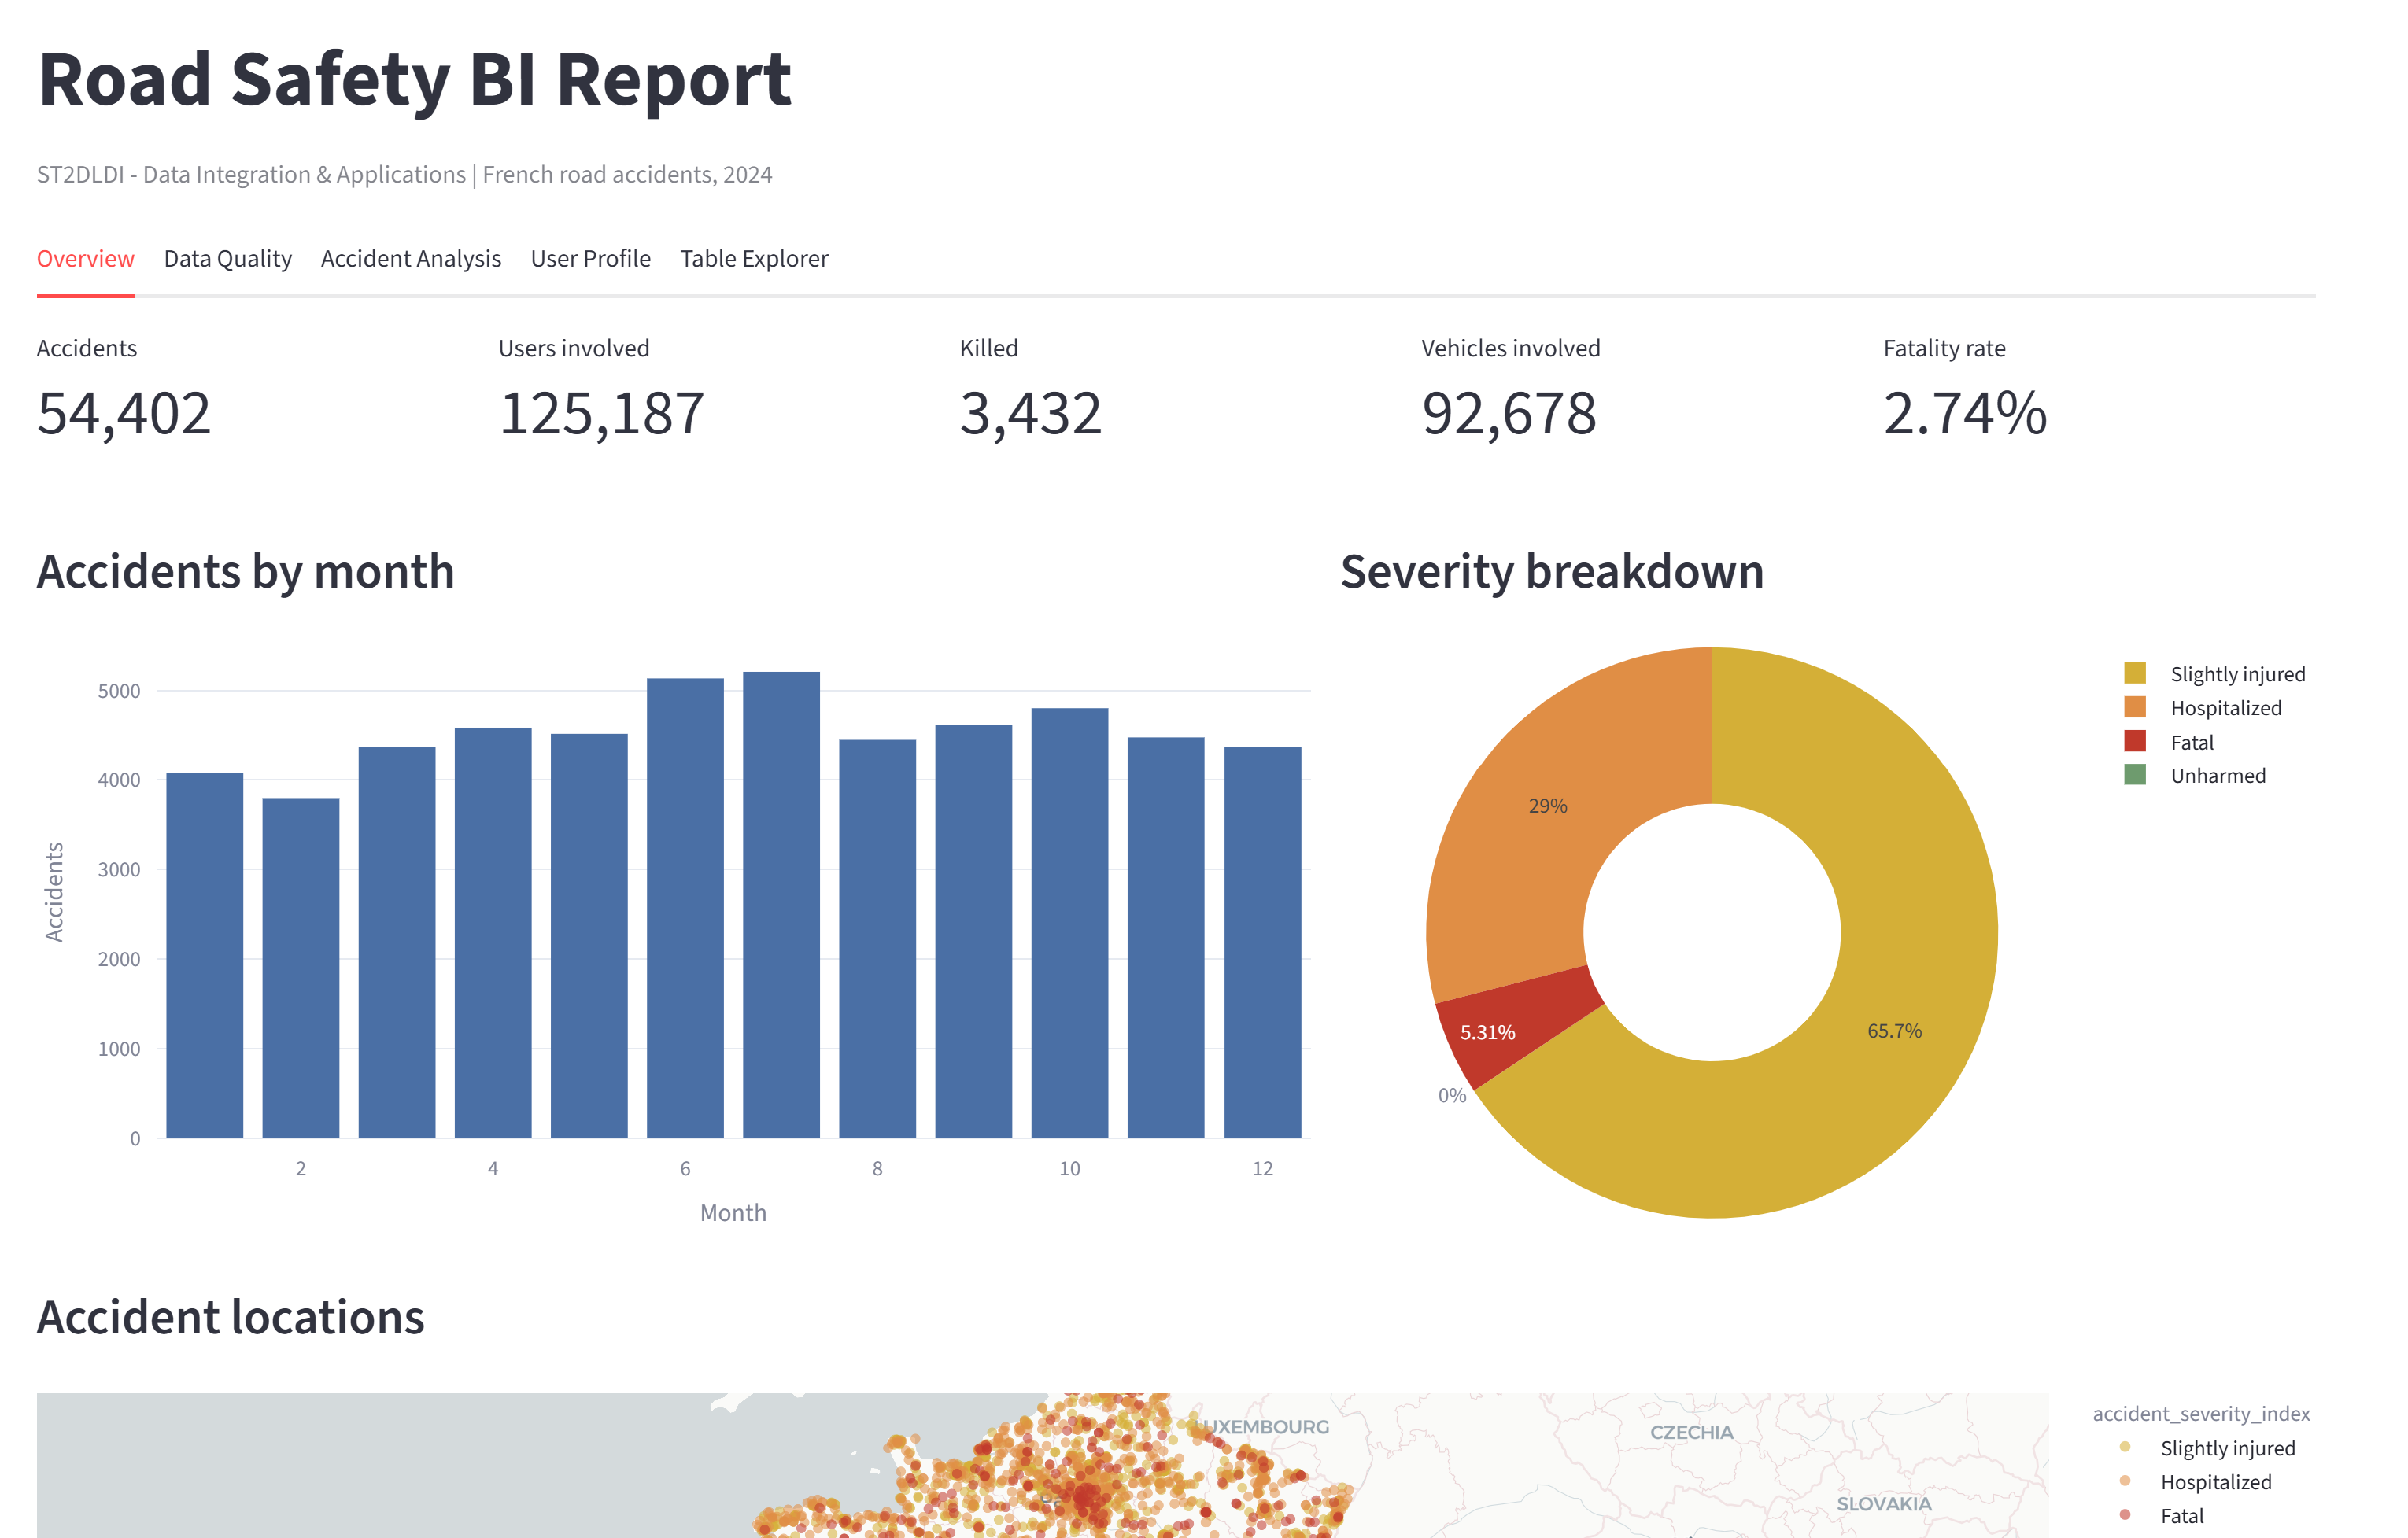

**Page 2: Data Quality**

The same quality scorecard, missing-value chart and GPS validity check as the Part 1.D quality report, plus an explicit impact analysis table (issue, affected table/column, downstream impact, priority), so both the quality report and the impact analysis questions are answered interactively.

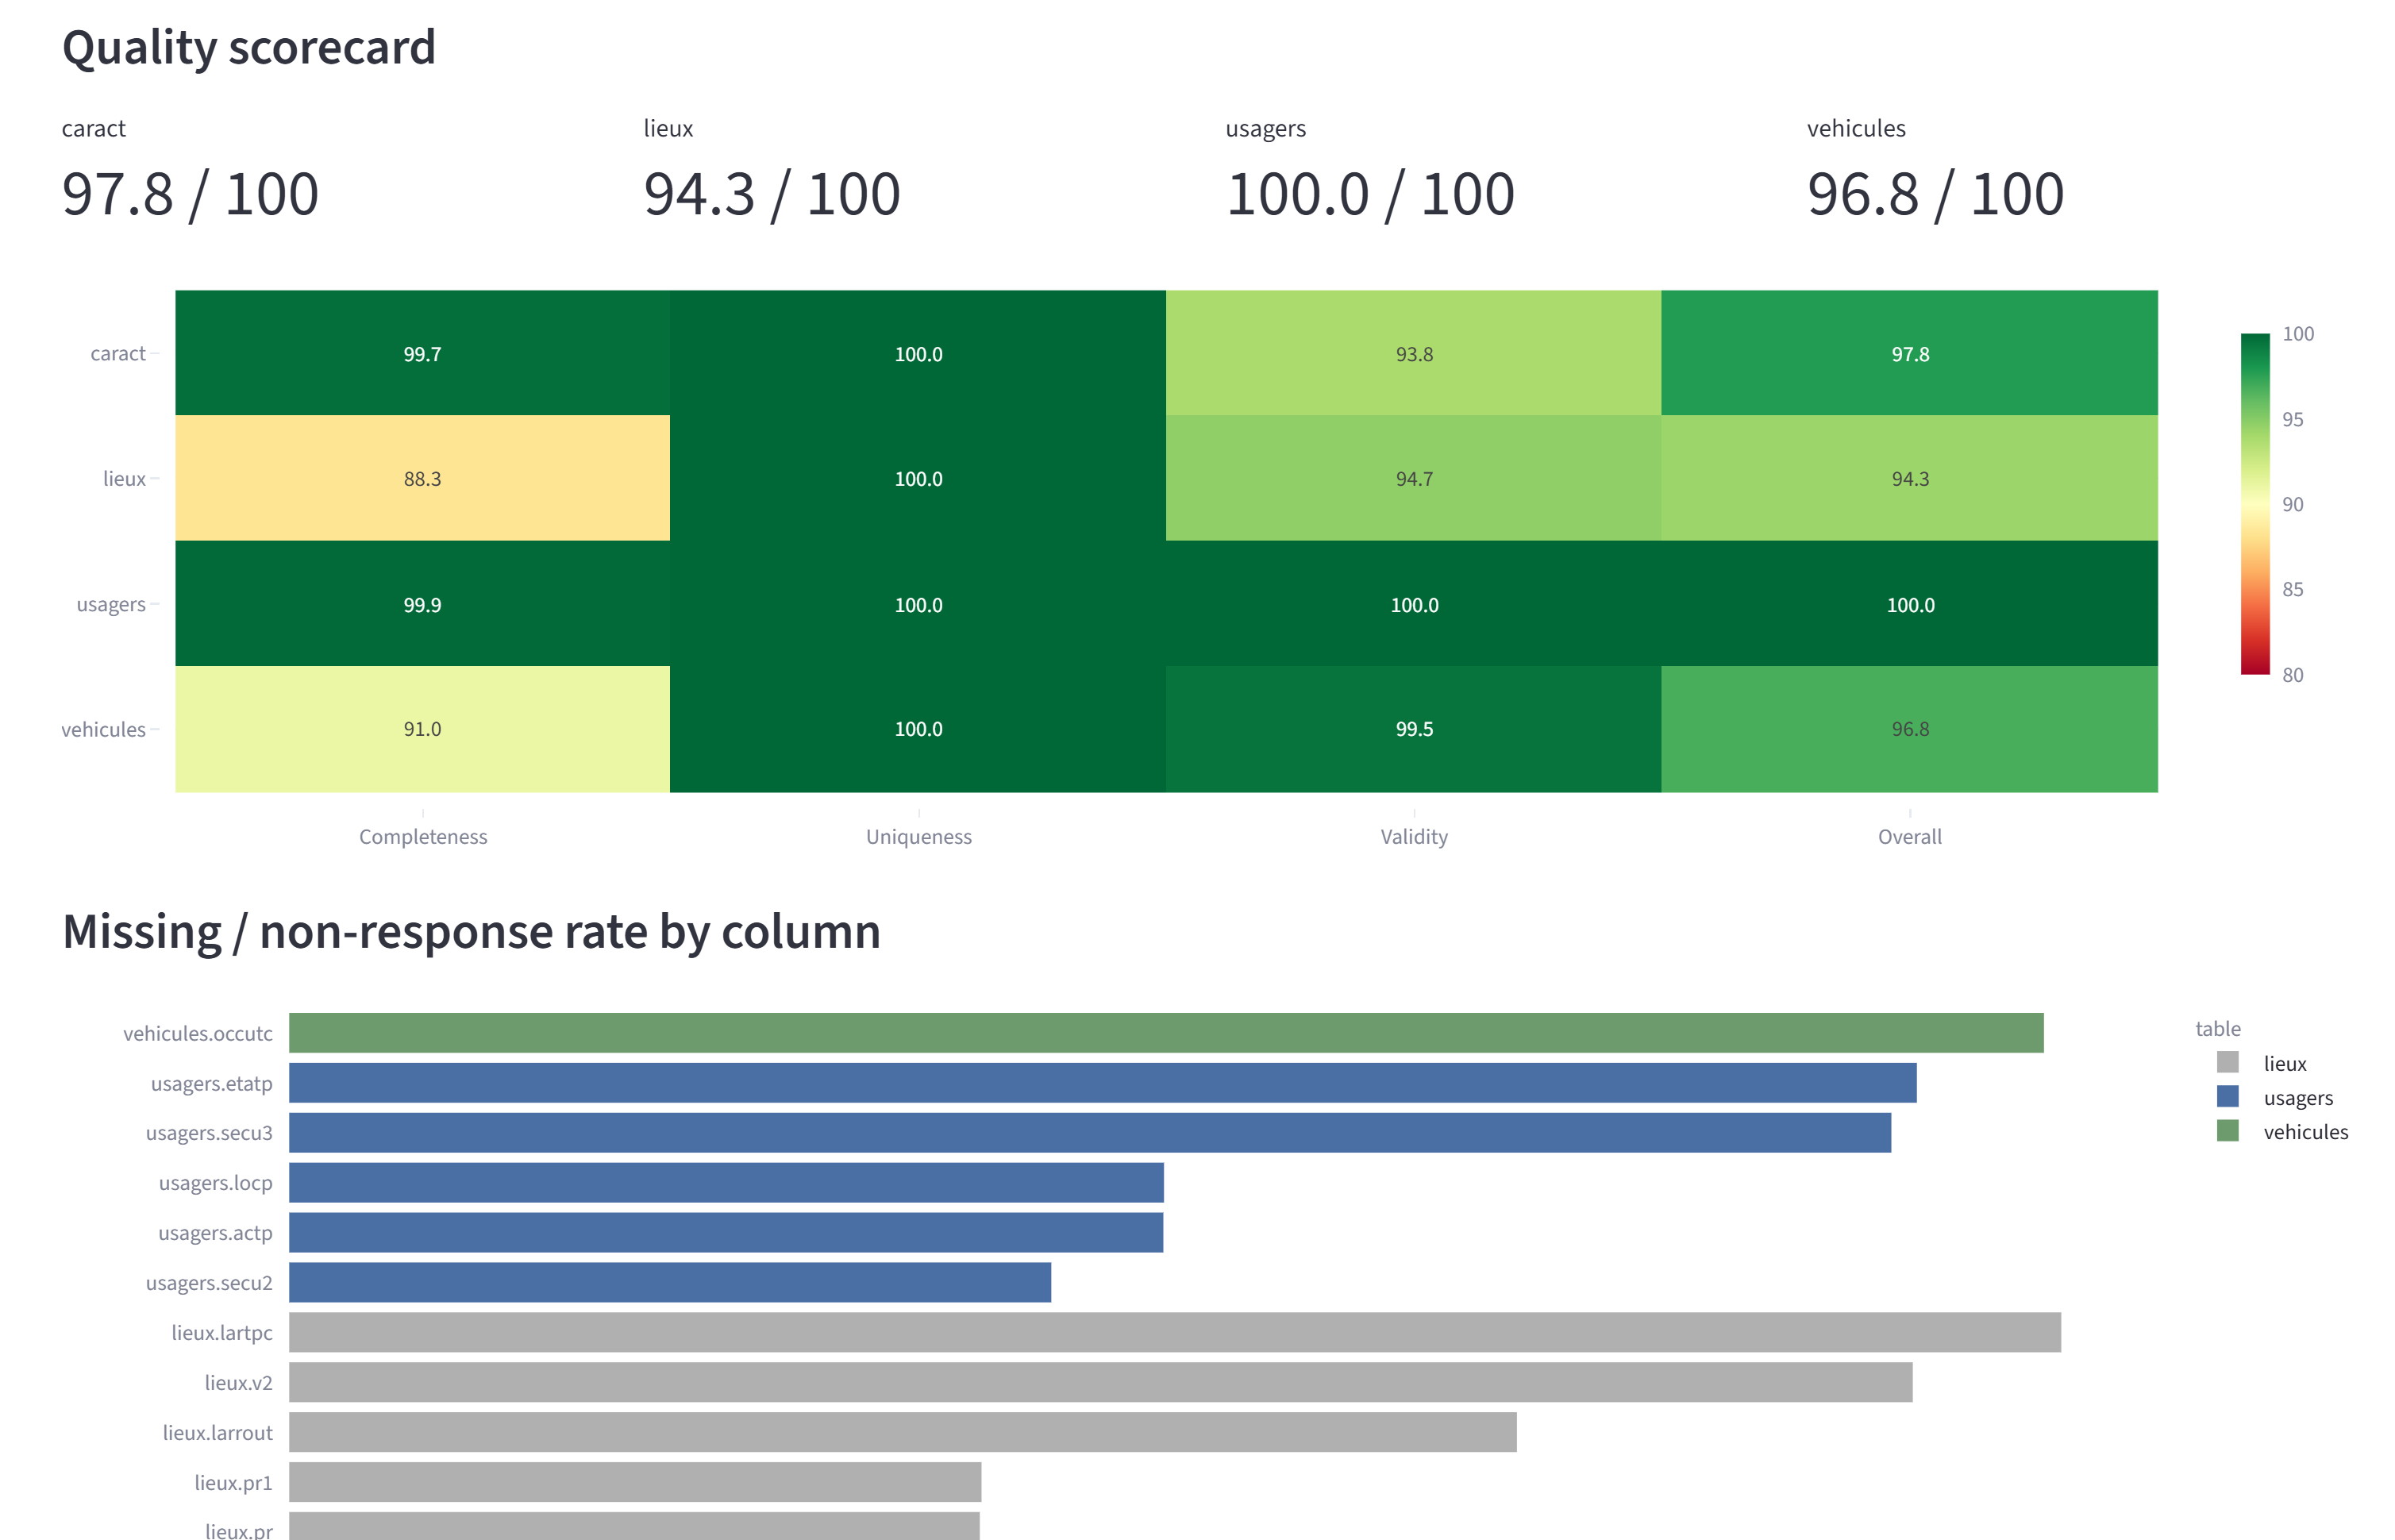

**Page 3: Accident Analysis**

Accidents by time of day and weather condition, fatality rate by road category, the top 10 departments, and the collision type distribution.

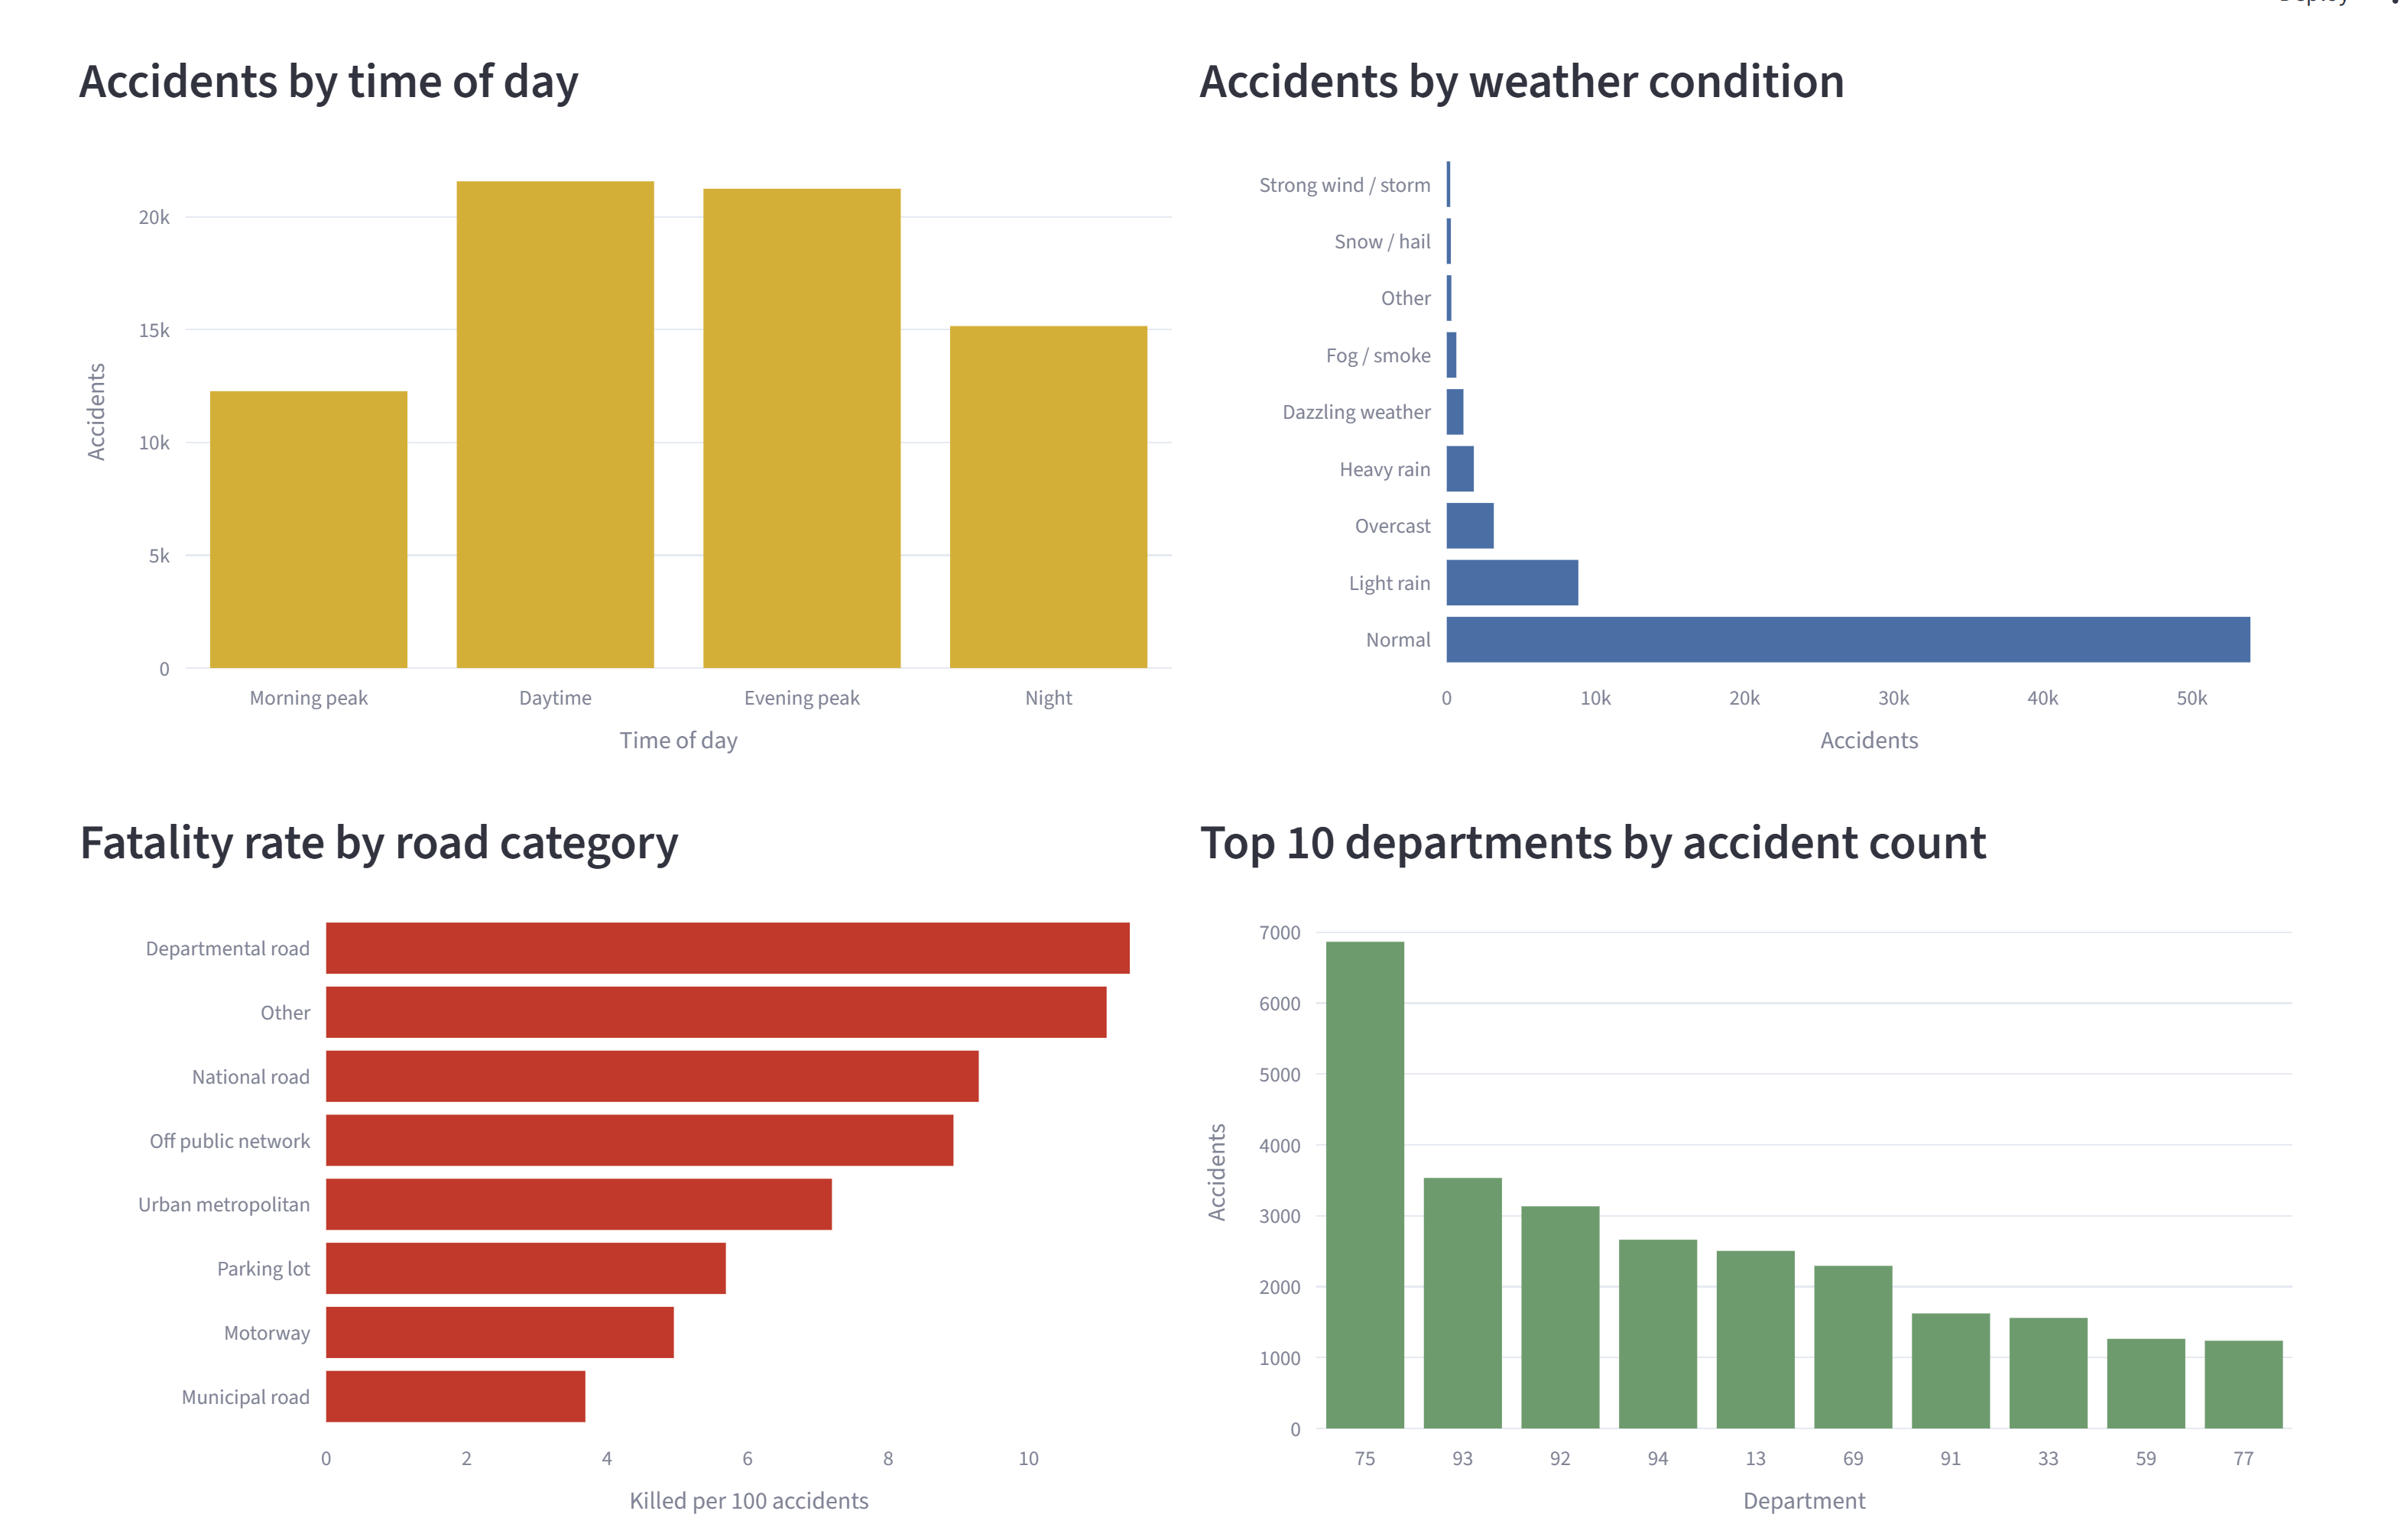

**Page 4: User Profile**

KPIs by user category (driver, passenger, pedestrian), and severity breakdowns by age group and by sex.

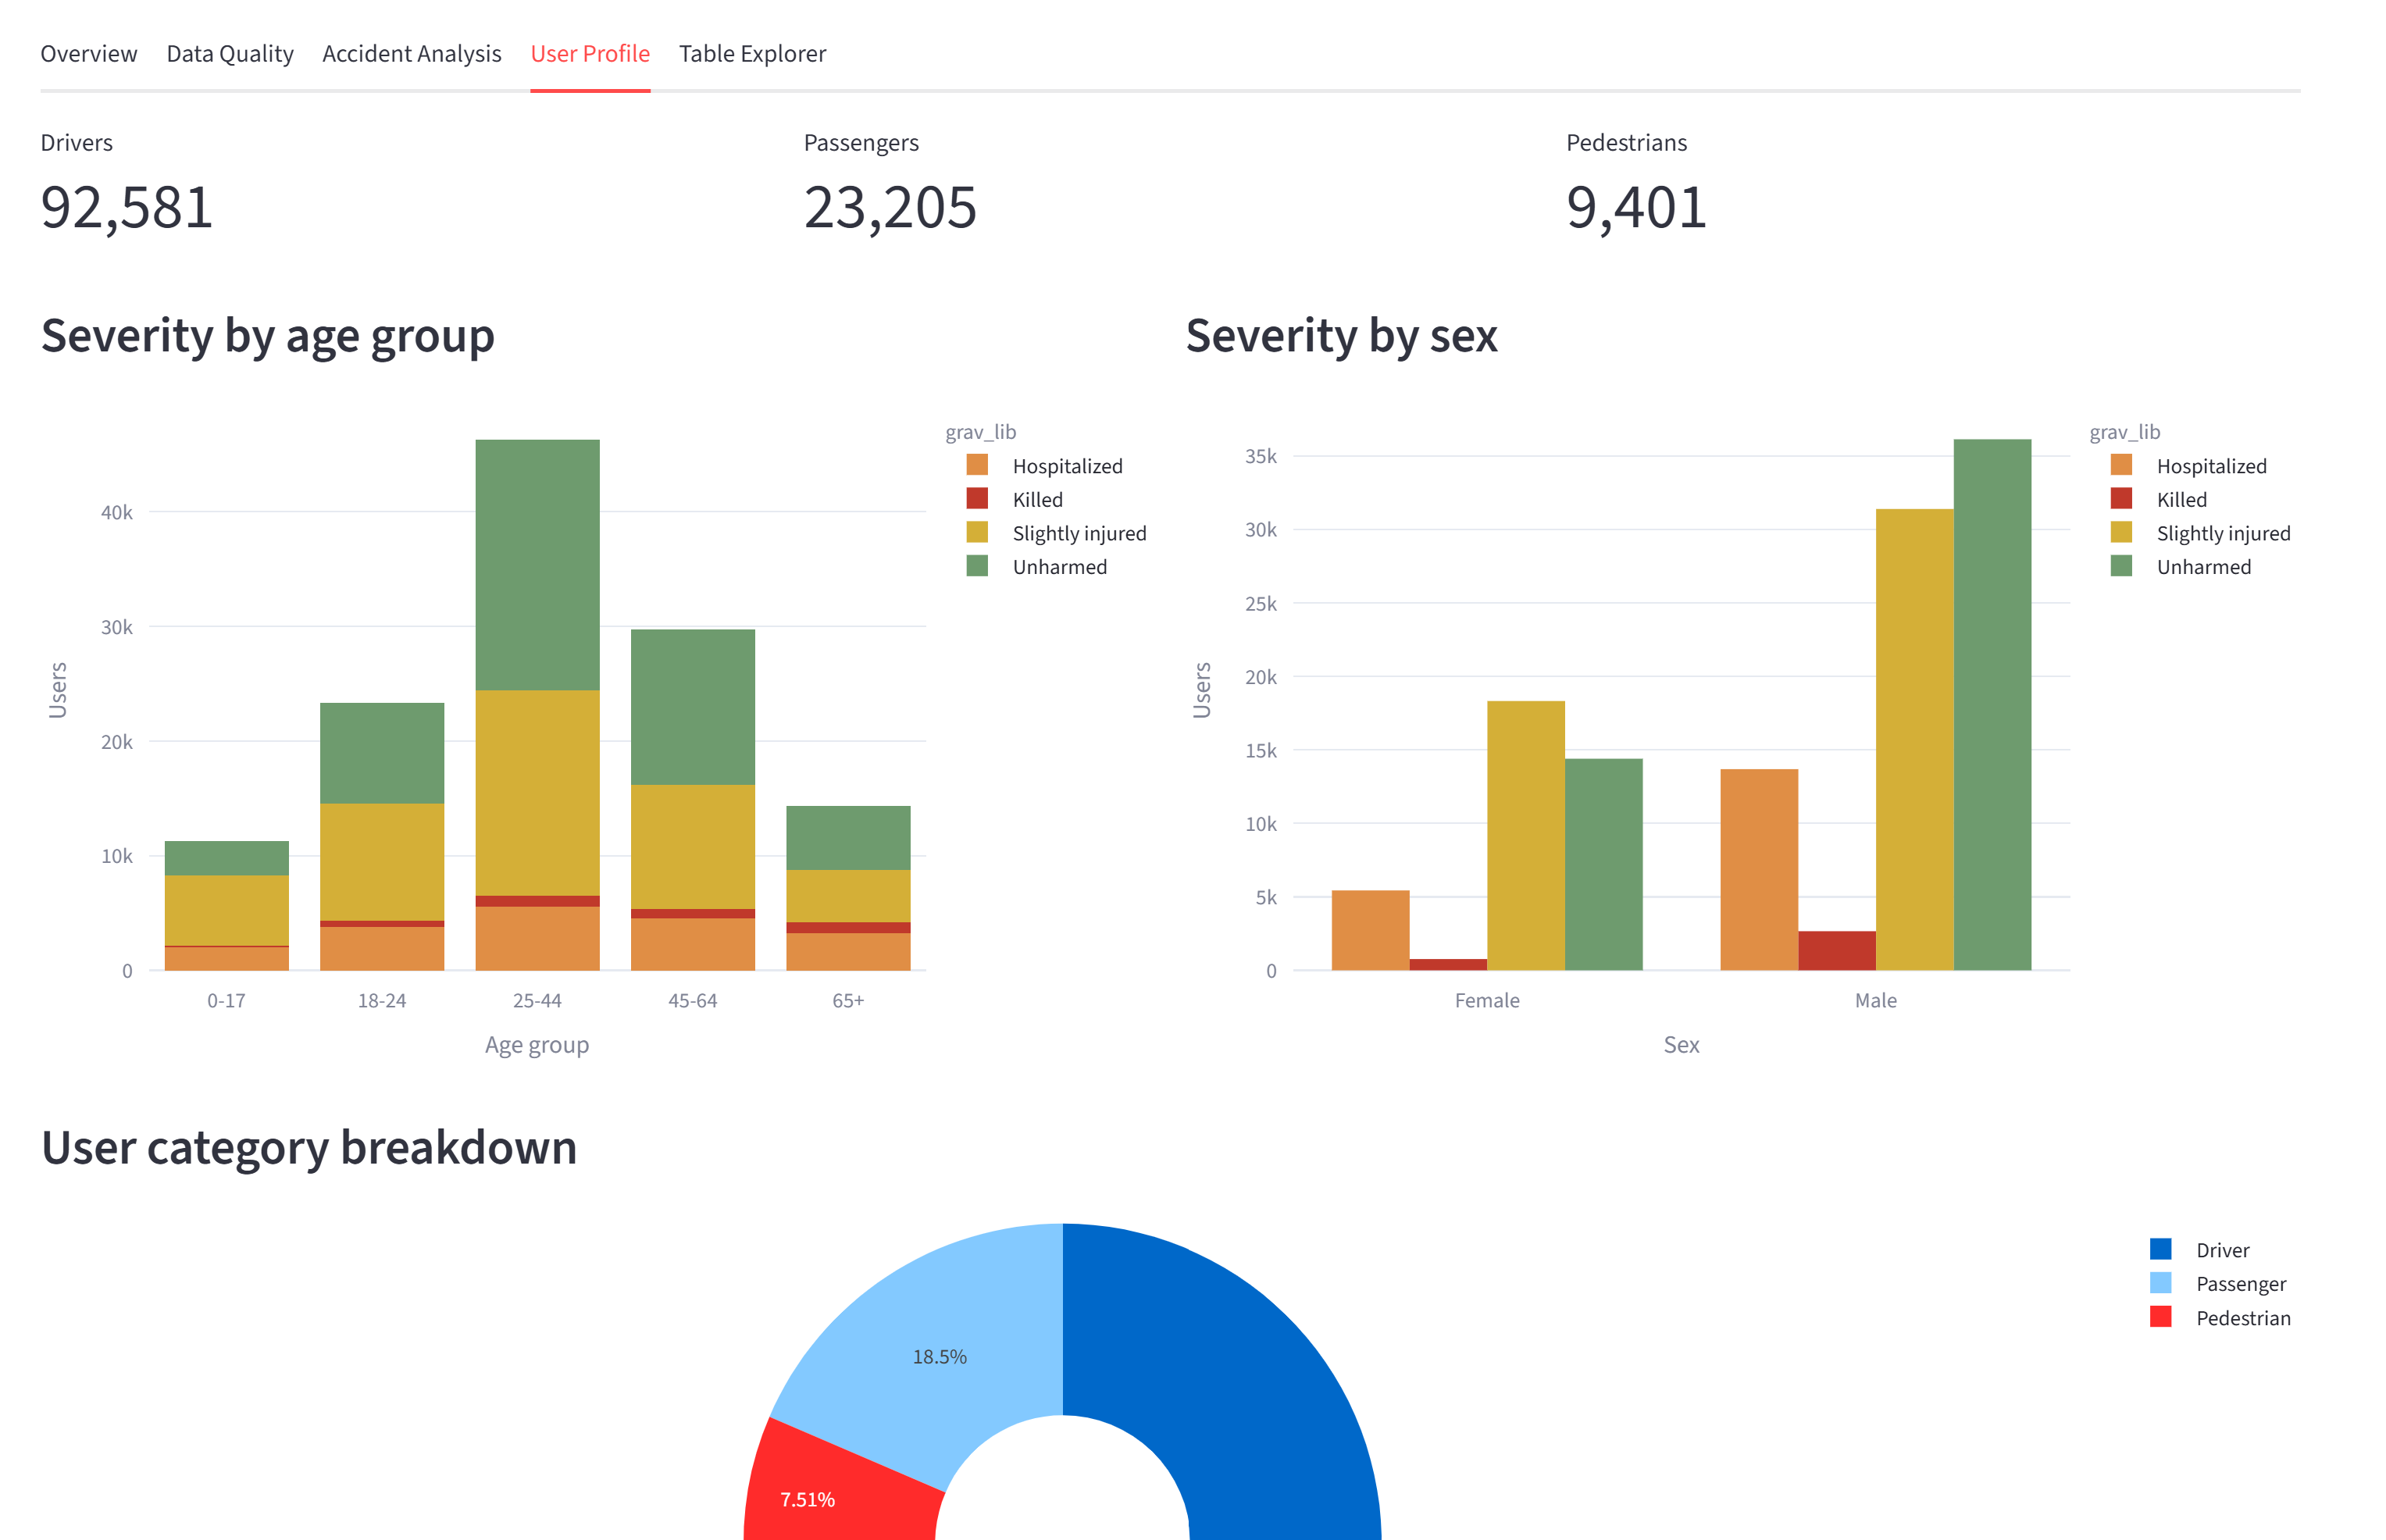

**Page 5: Table Explorer**

A dedicated per-table view, independent of the merged fact table used on the other pages. It lets the user pick any of the four raw Bronze tables (`caract`, `lieux`, `usagers`, `vehicules`) and shows its row and column counts, its missing-cell and duplicate-row counts, a full column summary (dtype, percentage missing, number of distinct values), and an interactive distribution chart for any column selected from a dropdown, a histogram for numeric fields and a bar chart of the most frequent values for categorical ones.

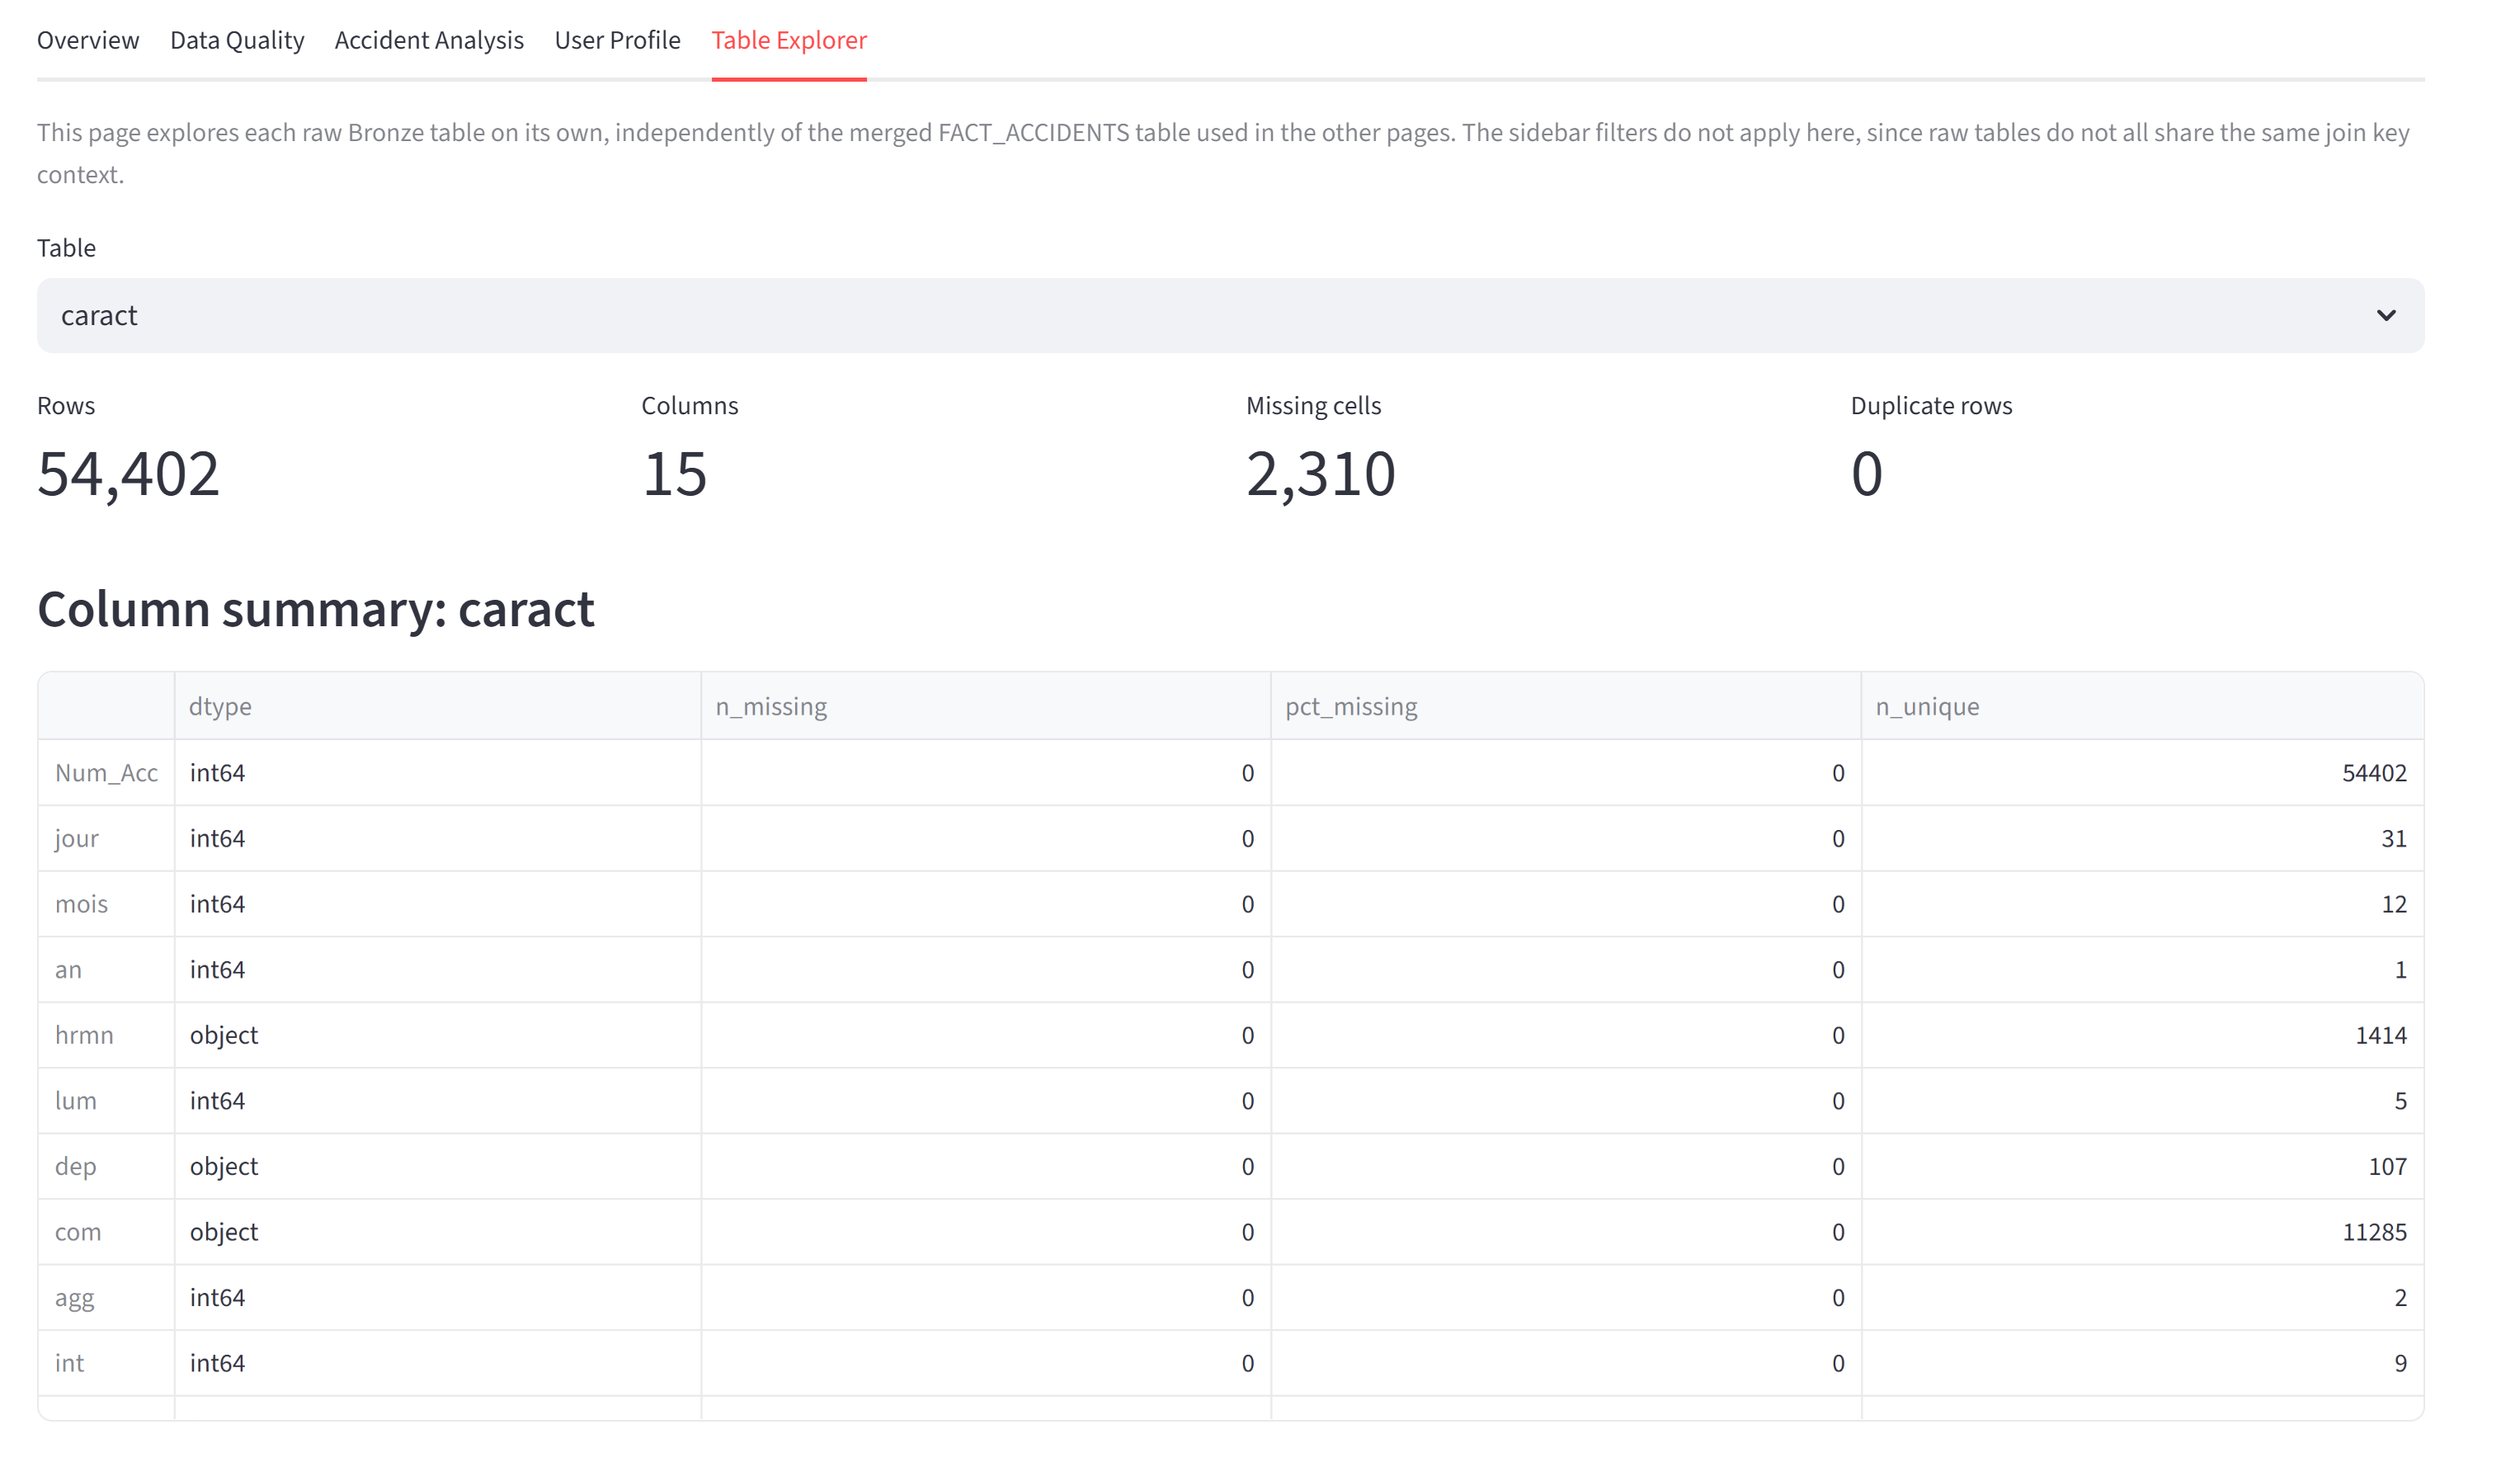

The Overview, Data Quality, Accident Analysis and User Profile pages share the same sidebar filters (zone, time of day, severity, weather condition), so selecting, for example, `Fatal` in the severity filter updates every KPI and chart across the page at once, the same way a Power BI report page would behave. The Table Explorer page works directly on the raw tables and is intentionally left outside of these filters, since it is meant to audit the source data rather than the filtered analysis.


# Part 2: Transformations, Modeling and Medallion Architecture

## A. Required Transformations (Silver Layer)

Based on the issues identified in the Part 1 quality report, this section applies and justifies the Bronze to Silver transformation plan, column by column. Each of the five required steps (standardization, cleaning, enrichment, deduplication, documentation) is implemented and then compared to the raw Bronze tables.

### Standardization

In [8]:
silver_caract = caract.copy()

# 1) Date: build a single standardized datetime column from jour/mois/an/hrmn
silver_caract['date_heure'] = pd.to_datetime(
    silver_caract['an'].astype(str) + '-' +
    silver_caract['mois'].astype(str).str.zfill(2) + '-' +
    silver_caract['jour'].astype(str).str.zfill(2) + ' ' +
    silver_caract['hrmn'],
    format='%Y-%m-%d %H:%M', errors='coerce'
)

# 2) lat/long: comma to point, cast to float, and flag rows outside mainland France
silver_caract['lat']  = silver_caract['lat'].astype(str).str.replace(',', '.').astype(float)
silver_caract['long'] = silver_caract['long'].astype(str).str.replace(',', '.').astype(float)
silver_caract['zone_geo'] = np.where(
    silver_caract['lat'].between(41, 51.5) & silver_caract['long'].between(-5.5, 10),
    'Mainland', 'Overseas / to verify'
)

# 3) Human-readable category labels for the fields most used downstream (BI-friendly),
#    based on the official ONISR BAAC nomenclature
lum_labels = {1: 'Daylight', 2: 'Dusk or dawn', 3: 'Night, no public lighting',
              4: 'Night, public lighting off', 5: 'Night, public lighting on'}
atm_labels = {1: 'Normal', 2: 'Light rain', 3: 'Heavy rain', 4: 'Snow / hail',
              5: 'Fog / smoke', 6: 'Strong wind / storm', 7: 'Dazzling weather',
              8: 'Overcast', 9: 'Other'}
col_labels = {1: 'Head-on', 2: 'Rear-end', 3: 'Side impact', 4: 'Chain collision',
              5: 'Multiple collision', 6: 'Other collision', 7: 'No collision'}

silver_caract['lum_label'] = silver_caract['lum'].map(lum_labels)
silver_caract['atm_label'] = silver_caract['atm'].map(atm_labels).fillna('Not specified')
silver_caract['col_label'] = silver_caract['col'].map(col_labels).fillna('Not specified')

print(silver_caract[['Num_Acc', 'date_heure', 'lat', 'long', 'zone_geo', 'lum_label', 'atm_label']].head())
print("\nZone breakdown:")
print(silver_caract['zone_geo'].value_counts())


        Num_Acc          date_heure        lat      long  zone_geo                  lum_label         atm_label
0  202400000001 2024-03-25 07:40:00  47.562770  6.758320  Mainland               Dusk or dawn       Fog / smoke
1  202400000002 2024-03-20 15:05:00  47.021090  4.837550  Mainland                   Daylight  Dazzling weather
2  202400000003 2024-03-22 19:30:00  44.902384  2.496418  Mainland               Dusk or dawn            Normal
3  202400000004 2024-03-24 17:50:00  49.191660 -0.398510  Mainland                   Daylight  Dazzling weather
4  202400000005 2024-03-25 19:35:00  43.390000  5.350000  Mainland  Night, public lighting on        Light rain

Zone breakdown:
zone_geo
Mainland                51055
Overseas / to verify     3347
Name: count, dtype: int64


Normalizing the date and time into a single standard `datetime` field makes temporal analysis easier, for example identifying peak hours or seasonality. Converting `lat`/`long` to `float` with a point decimal separator is required for any geospatial use, such as SQL filtering, mapping or distance calculations. Isolating the geographic zone avoids distorting maps centered on mainland France while still keeping the overseas records for other analyses. Mapping the weather, lighting and collision codes to readable labels removes the need for BI users to memorize the numeric nomenclature.

### Cleaning

In [9]:
silver_usagers = usagers.copy()
silver_lieux   = lieux.copy()
silver_veh     = vehicules.copy()

# Recode the -1 codes as explicit NaN ("not specified"), so they are no longer
# confused with a valid numeric value
cols_minus1_usagers = ['sexe', 'secu1', 'secu2', 'secu3', 'trajet', 'locp', 'actp', 'etatp']
for c in cols_minus1_usagers:
    silver_usagers[c] = silver_usagers[c].replace(-1, np.nan).replace('-1', np.nan)

cols_minus1_lieux = ['circ', 'nbv', 'vosp', 'vma', 'pr', 'pr1', 'larrout']
for c in cols_minus1_lieux:
    silver_lieux[c] = silver_lieux[c].astype(str).str.strip().replace('-1', np.nan)

# Drop columns that are nearly empty (over 95% missing) and considered unusable
silver_lieux = silver_lieux.drop(columns=['lartpc'])
silver_veh   = silver_veh.drop(columns=['occutc'])

# Clean the speed limit: values outside the 5-130 km/h plausible range are set to NaN
# rather than deleting the row, since the rest of the record remains usable
silver_lieux['vma'] = pd.to_numeric(silver_lieux['vma'], errors='coerce')
n_before = silver_lieux['vma'].notna().sum()
silver_lieux.loc[~silver_lieux['vma'].between(5, 130), 'vma'] = np.nan
n_after = silver_lieux['vma'].notna().sum()
print(f"lieux.vma: {n_before - n_after} implausible value(s) set to NaN "
      f"(kept {n_after} valid speed limits out of {n_before})")

# Surface condition label, used for readability in the Gold / BI layer
surf_labels = {1: 'Normal', 2: 'Wet', 3: 'Puddles', 4: 'Flooded', 5: 'Snow-covered',
               6: 'Mud', 7: 'Icy', 8: 'Grease / oil', 9: 'Other'}
silver_lieux['surf_label'] = silver_lieux['surf'].map(surf_labels).fillna('Not specified')

print("\nlieux columns after cleaning:", list(silver_lieux.columns))
print("vehicules columns after cleaning:", list(silver_veh.columns))


lieux.vma: 72 implausible value(s) set to NaN (kept 66546 valid speed limits out of 66618)

lieux columns after cleaning: ['Num_Acc', 'catr', 'voie', 'v1', 'v2', 'circ', 'nbv', 'vosp', 'prof', 'pr', 'pr1', 'plan', 'larrout', 'surf', 'infra', 'situ', 'vma', 'surf_label']
vehicules columns after cleaning: ['Num_Acc', 'id_vehicule', 'num_veh', 'senc', 'catv', 'obs', 'obsm', 'choc', 'manv', 'motor']


Recoding `-1` as `NaN` prevents this code from being used by mistake as a numeric value in statistical calculations such as averages or sums. Dropping `lartpc` and `occutc` avoids carrying unusable columns through to the Gold layer. Capping `vma` to a plausible range addresses the implausible speed limits identified in the Part 1 quality report, without discarding the rest of the record.

### Enrichment

In [10]:
# Accident severity index at the Num_Acc level, based on the worst case among the involved users
gravity_map = {1: 'Unharmed', 2: 'Killed', 3: 'Hospitalized', 4: 'Slightly injured'}
severity_rank = {1: 0, 4: 1, 3: 2, 2: 3}
silver_usagers['grav_lib'] = silver_usagers['grav'].map(gravity_map)
silver_usagers['grav_rank'] = silver_usagers['grav'].map(severity_rank)

acc_severity = silver_usagers.groupby('Num_Acc')['grav_rank'].max().reset_index()
rank_to_label = {0: 'Unharmed', 1: 'Slightly injured', 2: 'Hospitalized', 3: 'Fatal'}
acc_severity['accident_severity_index'] = acc_severity['grav_rank'].map(rank_to_label)
acc_severity = acc_severity[['Num_Acc', 'accident_severity_index']]

# Impute the missing birth years with the median, as proposed in the Part 1 remediation
# plan, and keep an explicit flag so the imputed rows remain traceable
silver_usagers['an_nais_imputed'] = silver_usagers['an_nais'].isna()
median_an_nais = silver_usagers['an_nais'].median()
silver_usagers['an_nais'] = silver_usagers['an_nais'].fillna(median_an_nais)

# Age group, derived from the (now complete) birth year
age_years = 2024 - silver_usagers['an_nais']
silver_usagers['age_group'] = pd.cut(
    age_years, bins=[0, 17, 24, 44, 64, 120],
    labels=['0-17', '18-24', '25-44', '45-64', '65+'], right=True
)

# Time-of-day category, derived from date_heure
def time_of_day(dt):
    if pd.isna(dt):
        return np.nan
    h = dt.hour
    if 6 <= h < 10:
        return 'Morning peak'
    if 10 <= h < 16:
        return 'Daytime'
    if 16 <= h < 20:
        return 'Evening peak'
    return 'Night'

silver_caract['time_of_day'] = silver_caract['date_heure'].apply(time_of_day)
silver_caract['age_moyen_usagers'] = silver_caract['Num_Acc'].map(
    (2024 - silver_usagers.groupby('Num_Acc')['an_nais'].mean())
)

silver_caract = silver_caract.merge(acc_severity, on='Num_Acc', how='left')

print(f"an_nais imputed for {silver_usagers['an_nais_imputed'].sum()} user(s) "
      f"using the median birth year ({int(median_an_nais)})")
print(silver_usagers[['Num_Acc', 'an_nais', 'age_group', 'grav_lib']].head())
print(silver_caract[['Num_Acc', 'date_heure', 'time_of_day', 'accident_severity_index']].head())


an_nais imputed for 2579 user(s) using the median birth year (1988)
        Num_Acc  an_nais age_group          grav_lib
0  202400000001   2003.0     18-24      Hospitalized
1  202400000001   1997.0     25-44          Unharmed
2  202400000002   1927.0       65+      Hospitalized
3  202400000002   1987.0     25-44          Unharmed
4  202400000003   2007.0      0-17  Slightly injured
        Num_Acc          date_heure   time_of_day accident_severity_index
0  202400000001 2024-03-25 07:40:00  Morning peak            Hospitalized
1  202400000002 2024-03-20 15:05:00       Daytime            Hospitalized
2  202400000003 2024-03-22 19:30:00  Evening peak            Hospitalized
3  202400000004 2024-03-24 17:50:00  Evening peak        Slightly injured
4  202400000005 2024-03-25 19:35:00  Evening peak        Slightly injured


The `accident_severity_index`, derived from the worst `grav` value among the involved users, provides an accident-level view of severity, which is convenient for a fact table where one row corresponds to one accident. The `time_of_day` field allows analysis by time slot without having to parse the `hrmn` text field repeatedly. Imputing `an_nais` with the median, while keeping an explicit `an_nais_imputed` flag, follows the remediation strategy from Part 1: no information is lost, and any downstream analysis can still exclude imputed rows if needed. The resulting `age_group` field turns a continuous variable into a small number of business-friendly buckets.

### Deduplication

In [11]:
before = len(silver_lieux)
silver_lieux = silver_lieux.drop_duplicates()
after = len(silver_lieux)
print(f"lieux: {before - after} duplicate row(s) removed ({before} to {after} rows)")

for name, df in [('caract', silver_caract), ('usagers', silver_usagers), ('vehicules', silver_veh)]:
    d = df.duplicated().sum()
    print(f"{name}: {d} remaining duplicate row(s)")


lieux: 2 duplicate row(s) removed (70248 to 70246 rows)
caract: 0 remaining duplicate row(s)
usagers: 0 remaining duplicate row(s)
vehicules: 0 remaining duplicate row(s)


### Documentation

Summary of the Bronze to Silver transformations applied.

| Step | Table(s) | Transformation |
|---|---|---|
| Standardization | caract | Merge `jour`/`mois`/`an`/`hrmn` into `date_heure` (datetime) |
| Standardization | caract | Convert `lat`/`long` from comma to point decimal, cast to float, add `zone_geo` flag |
| Standardization | caract, lieux | Map `lum`, `atm`, `col`, `surf` codes to readable labels |
| Cleaning | usagers, lieux | Recode `-1` as explicit `NaN` ("not specified") |
| Cleaning | lieux, vehicules | Drop nearly empty columns (`lartpc`, `occutc`) |
| Cleaning | lieux | Cap `vma` to the plausible 5 to 130 km/h range |
| Enrichment | usagers to caract | `accident_severity_index` (maximum severity per accident) |
| Enrichment | caract | `time_of_day` (time slot), `age_moyen_usagers` |
| Enrichment | usagers | Median imputation of `an_nais` (with `an_nais_imputed` flag), `age_group` bucket |
| Deduplication | lieux | Remove 2 strictly duplicated rows |

Each transformation is traced directly in this notebook, since the source code itself serves as executable documentation, with the business reasoning explained after each step.

## B. Modeling (Gold Layer)

A star schema is proposed for road safety analysis, built around a fact table, `FACT_ACCIDENTS`, surrounded by four dimension tables.

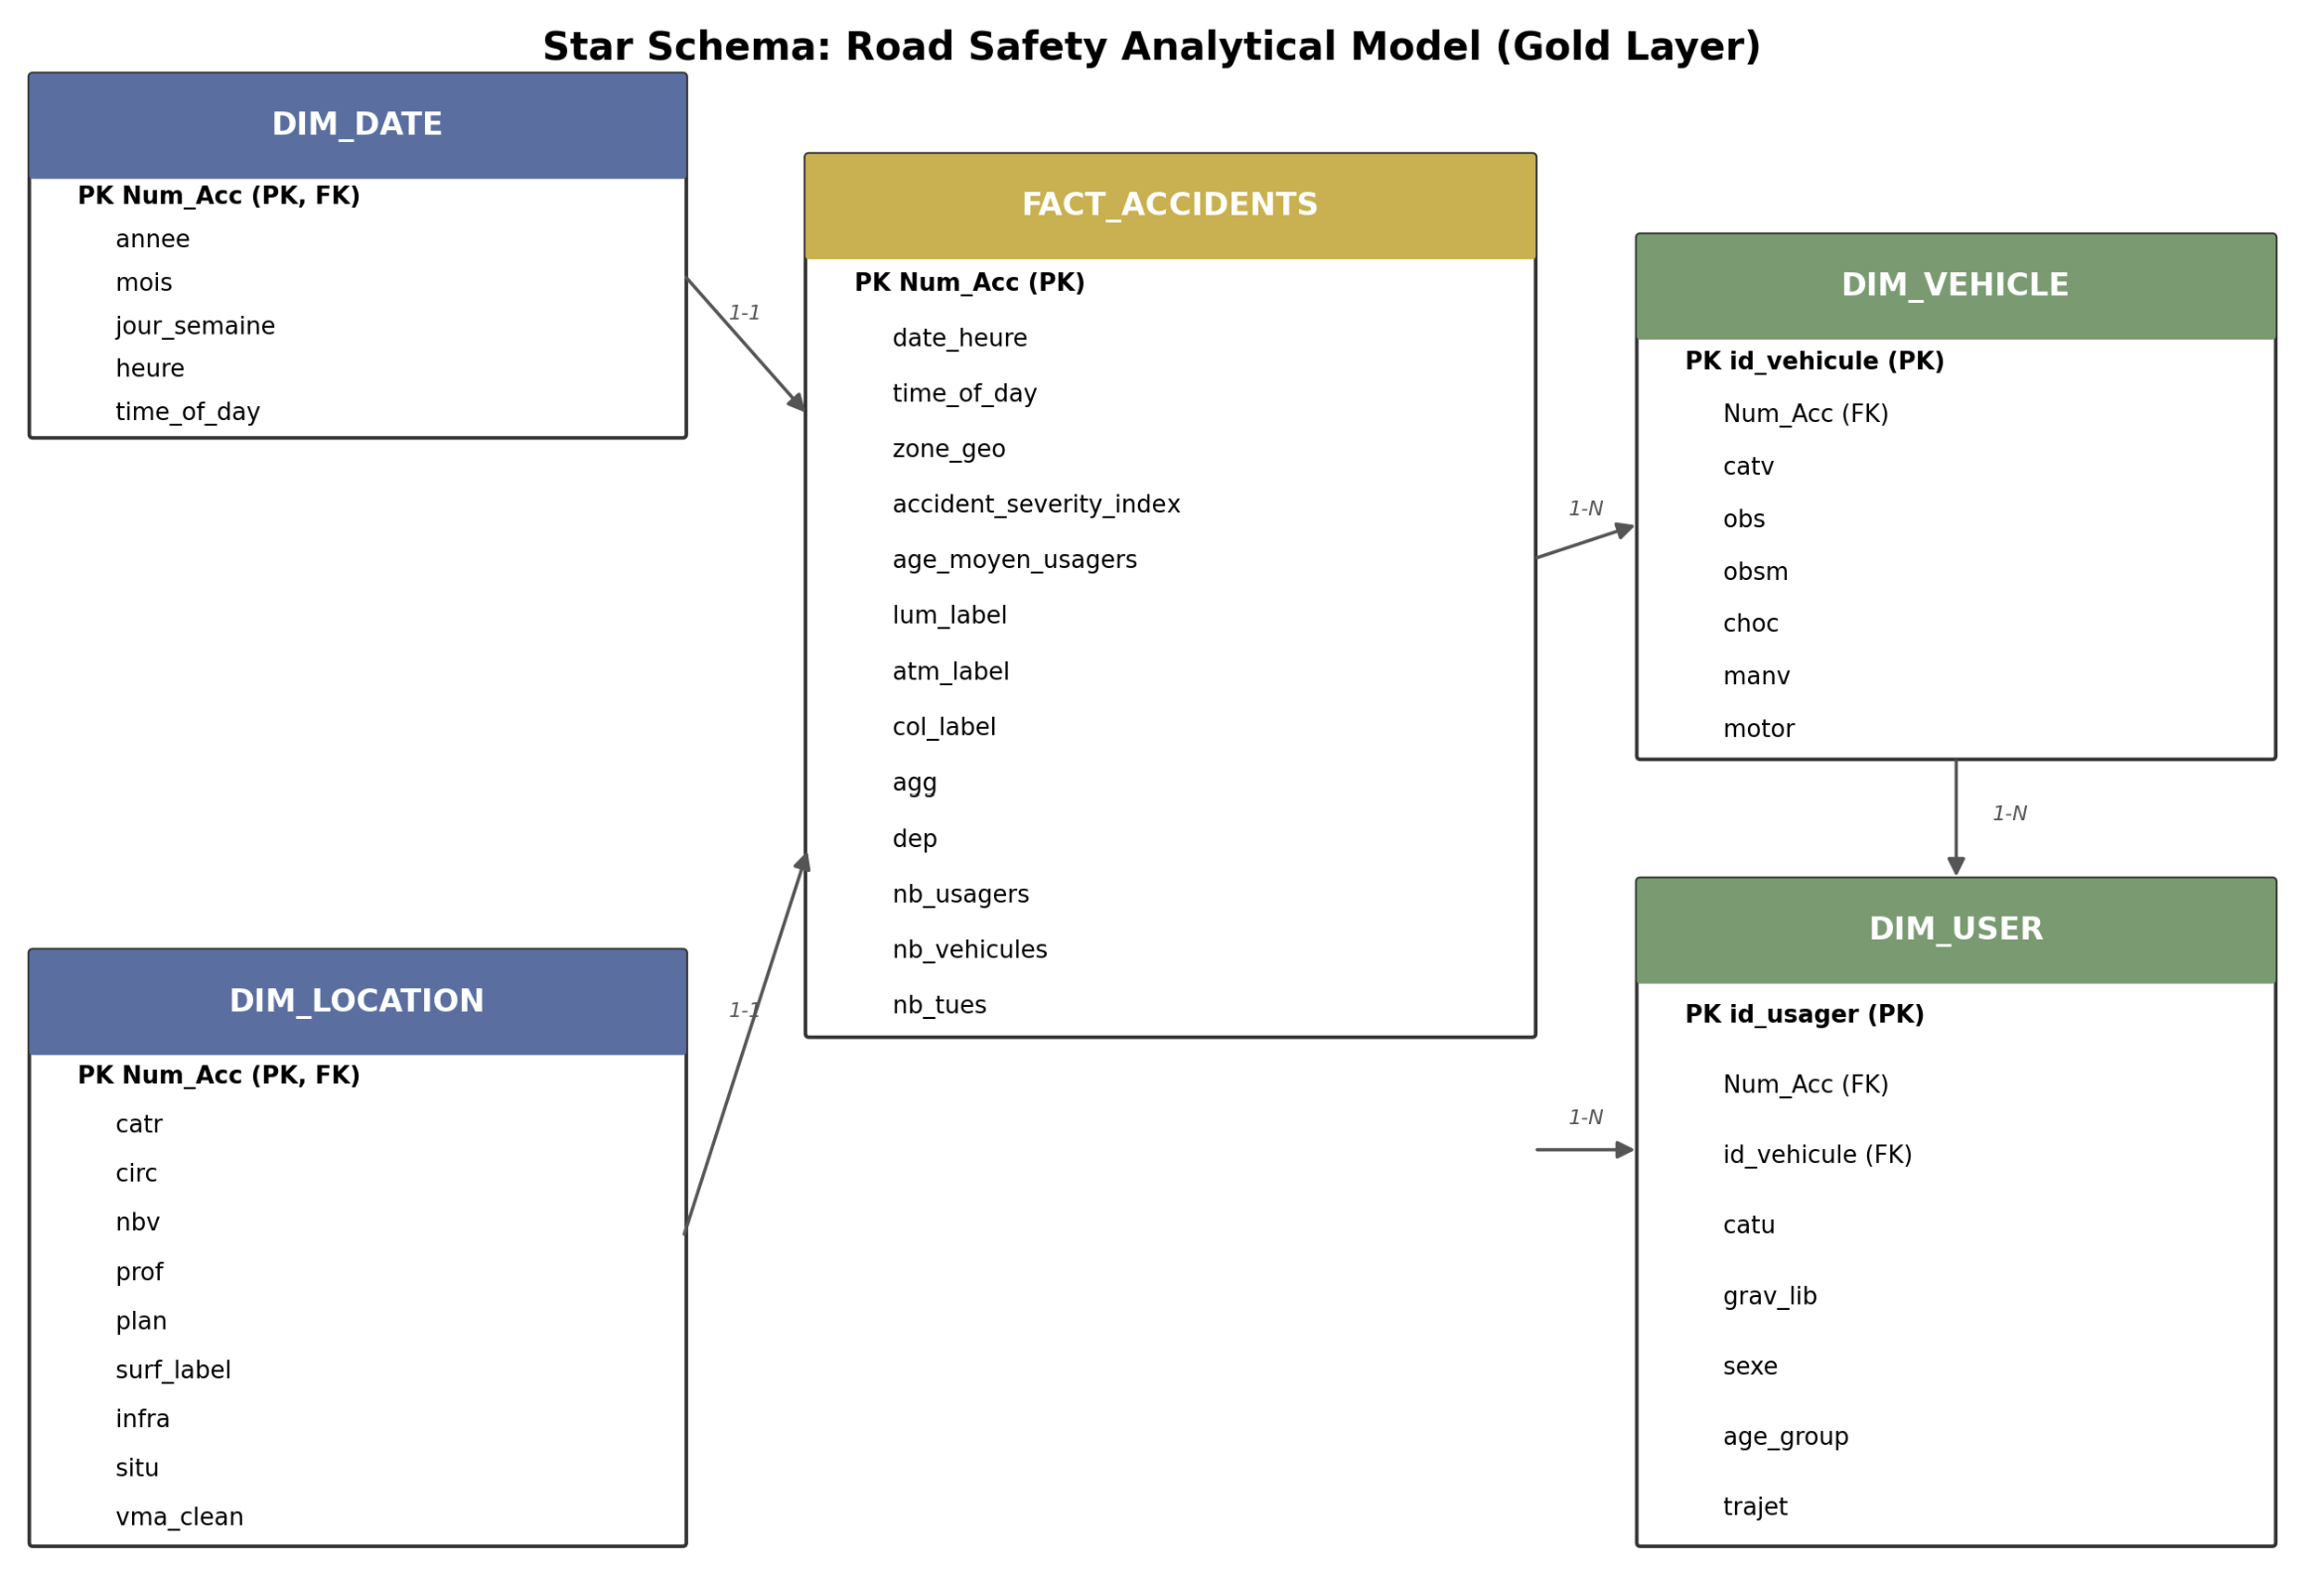



## C. Medallion Architecture Diagram

The diagram below summarizes the full pipeline implemented in this notebook, from the raw open data files (Bronze) to the cleaned, standardized and enriched tables (Silver), the star schema analytical model (Gold), and the BI / dashboards final consumption layer. It reflects the refined Silver layer built in Part 2.A, including the category label mapping, the `vma` cleaning and the `an_nais` imputation. That last layer, the interactive BI report, is built and presented in Part 1.D, right after the quality report.

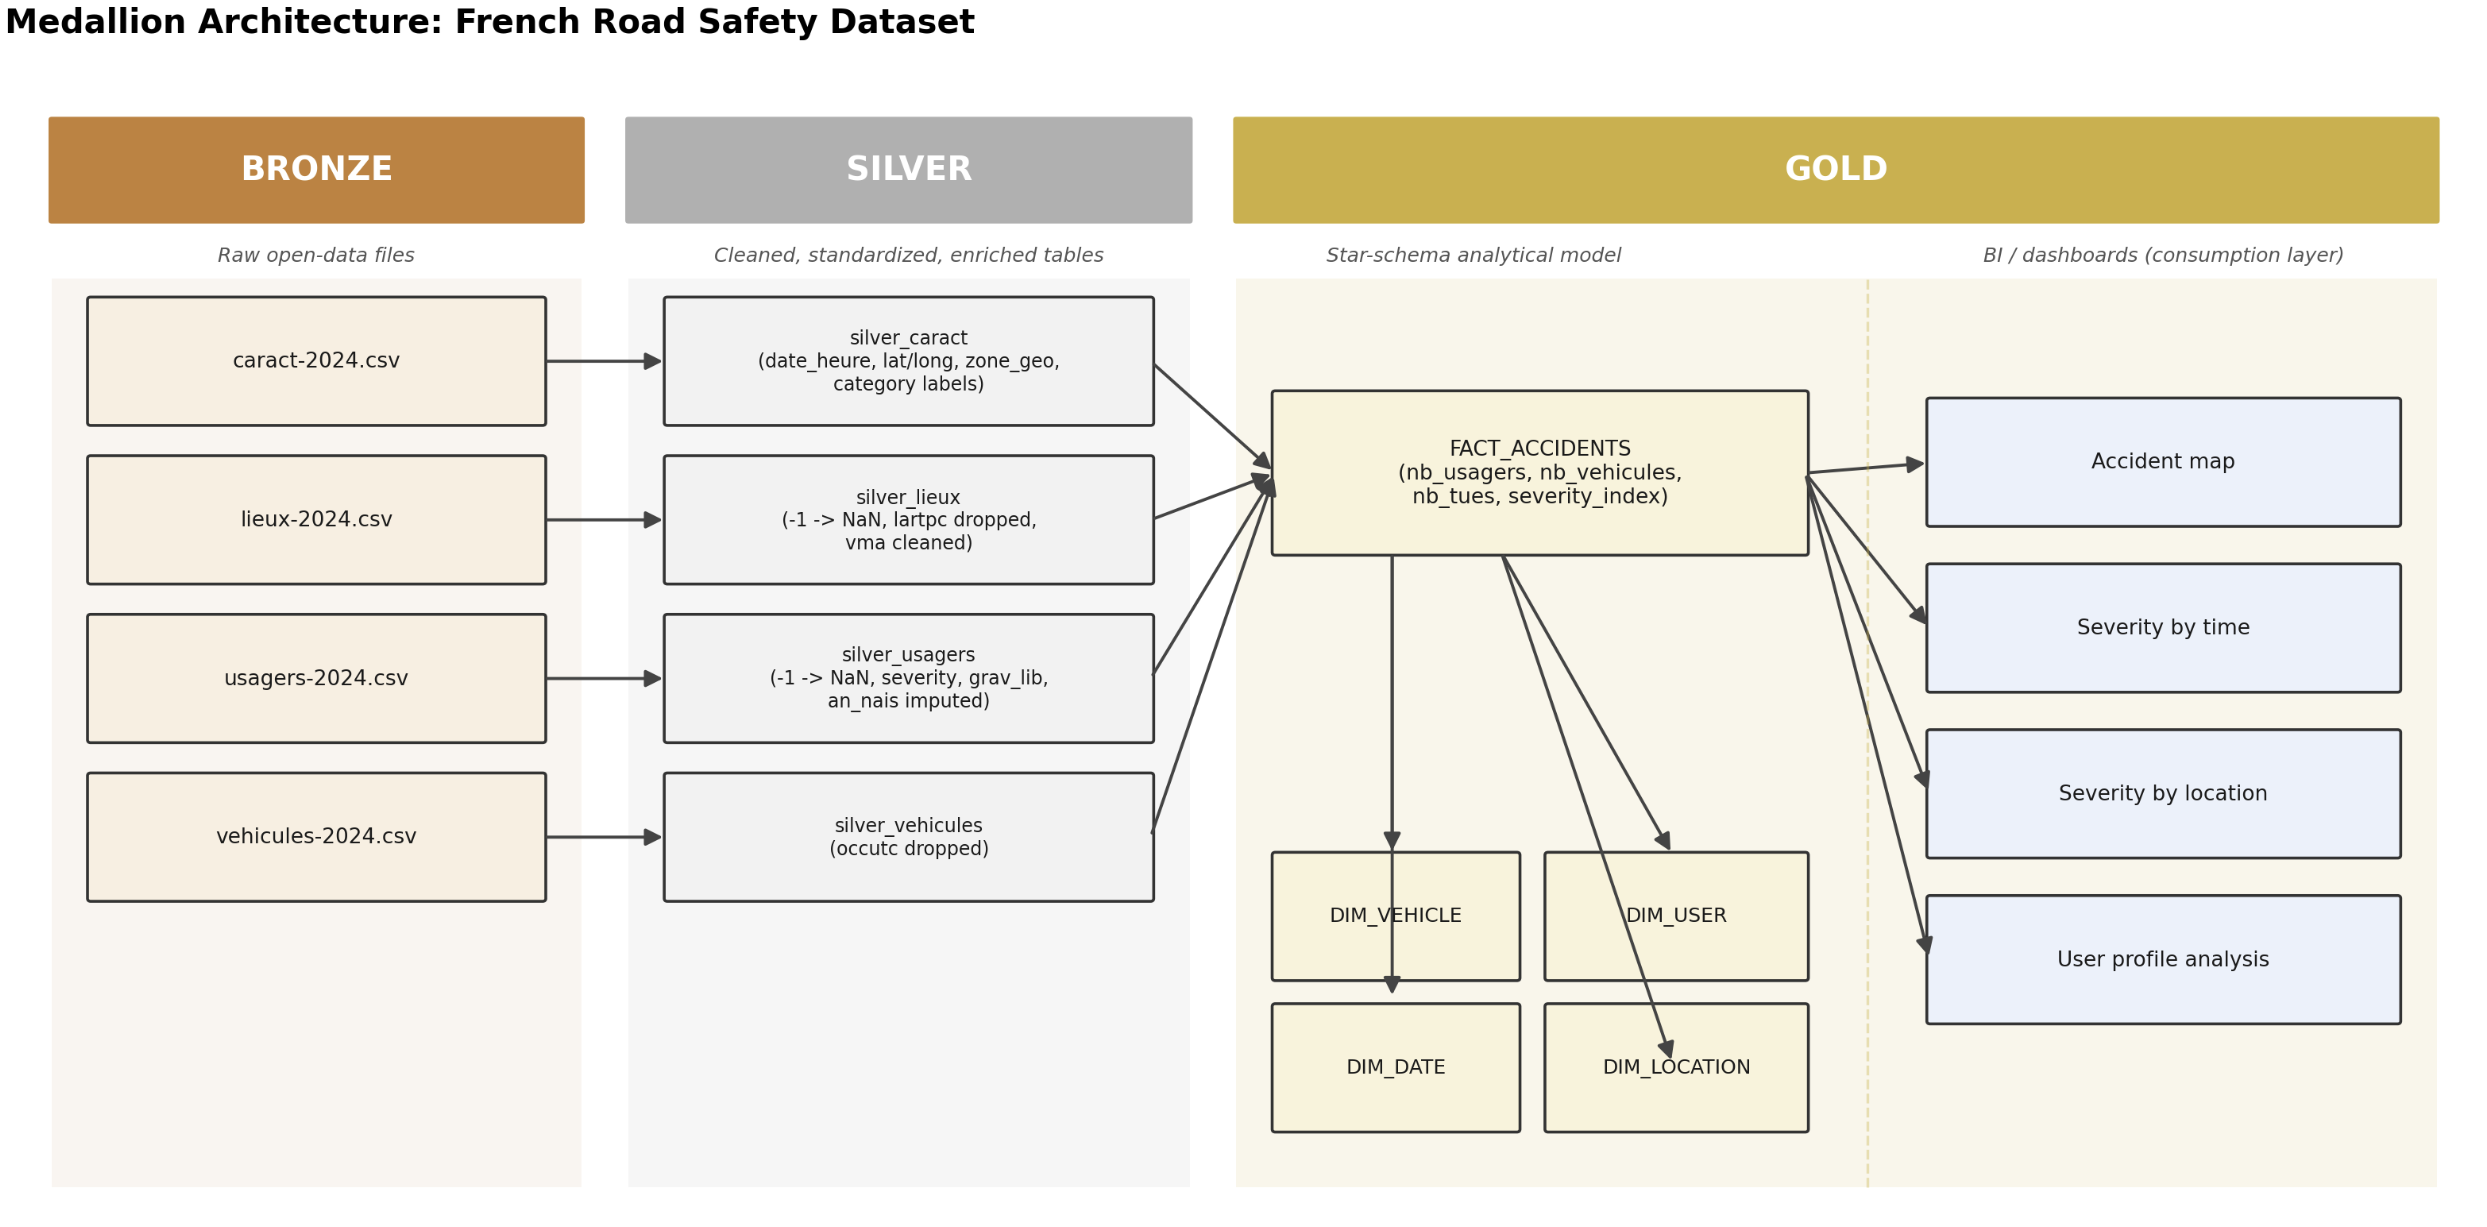

**Short justification of design choices**

The fact table is built at the accident level (`Num_Acc`), not at the user or vehicle level, since the goal is road-safety analysis and an accident is the natural unit of analysis. Counts like `nb_usagers` or `nb_tues` are pre-aggregated into the fact table so they don't need to be recomputed from `usagers` and `vehicules` every time.

`lartpc` and `occutc` were dropped in the Silver layer instead of kept and ignored, since they are almost entirely empty and would only add noise to the Gold model. `vma`, on the other hand, was cleaned rather than dropped, because only a small share of its values were invalid, so most of the field is still useful.

The `-1` codes are recoded to `NaN` instead of left as is, mainly to avoid them being silently included in averages or sums later on. Missing birth years are imputed with the median rather than dropped, with a flag column kept so imputed rows can still be excluded if needed for a specific analysis.

A star schema was used instead of a snowflake schema. It's slightly less normalized, but the joins stay simple, which matters more here since the Gold layer is meant to feed a BI tool directly. For the same reason, category codes are translated into readable labels (e.g. `atm_label`) already in the Silver layer, so the BI layer doesn't need a separate lookup table for the ONISR nomenclature.